# Mean-Variance Optimization (MVO): From Theory to Real Code

---

## What This Notebook Covers

You know the *idea* behind MVO — pick portfolio weights that give you the best return for a given level of risk. But how does that actually work in code? This notebook closes that gap.

```
Theory You Know          Gap This Notebook Fills          Real Implementation
─────────────────        ──────────────────────────       ────────────────────
"Diversification         How do you actually compute      numpy, scipy, pypfopt
 reduces risk"           the covariance matrix?           doing the heavy lifting

"Efficient frontier       How do you solve for the        Quadratic programming
 is the best set          weights mathematically?         under constraints
 of portfolios"

"Markowitz 1952"         Why does textbook MVO fail      Estimation error,
                          in practice, and what do        shrinkage, Black-Litterman,
                          practitioners actually do?      robust methods
```

### Roadmap

| Part | What | Why |
|------|------|-----|
| **1** | The two inputs: expected returns & covariance | You can't optimize without these |
| **2** | MVO from scratch (numpy + scipy) | Understand what the optimizer is actually doing |
| **3** | The efficient frontier | Visualize the full set of optimal portfolios |
| **4** | Adding constraints (no shorting, position limits) | Textbook MVO is unconstrained — real life isn't |
| **5** | Using `PyPortfolioOpt` (the industry library) | What you'd actually use in practice |
| **6** | Why textbook MVO fails & what practitioners do | Estimation error, shrinkage, Black-Litterman |
| **7** | Out-of-sample test: does MVO actually work? | Backtest MVO vs. naive strategies |

In [133]:
!pip install -q yfinance pandas numpy matplotlib scipy
!pip install -q PyPortfolioOpt
!pip install -q seaborn

print('All libraries installed!')

All libraries installed!


In [134]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)

# Download a diversified set of stocks
# Tech, Finance, Energy, Healthcare, Consumer — different sectors so diversification matters
TICKERS = ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'PG', 'GOOGL', 'BRK-B']
SECTOR_MAP = {
    'AAPL': 'Tech', 'MSFT': 'Tech', 'GOOGL': 'Tech',
    'JPM': 'Finance', 'BRK-B': 'Finance',
    'XOM': 'Energy', 'JNJ': 'Healthcare', 'PG': 'Consumer'
}

raw = yf.download(TICKERS, start='2018-01-01', end='2025-12-31', auto_adjust=False)

# Handle MultiIndex columns from yfinance
# raw.columns is like [('Adj Close', 'AAPL'), ('Adj Close', 'MSFT'), ...]
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Adj Close'].dropna()
else:
    prices = raw[['Adj Close']].dropna()
    prices.columns = TICKERS

# Flatten any remaining MultiIndex on columns
if isinstance(prices.columns, pd.MultiIndex):
    prices.columns = prices.columns.get_level_values(-1)

# Daily returns
returns = prices.pct_change().dropna()

print(f'Stocks: {list(prices.columns)}')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
print(f'Trading days: {len(returns)}')
print(f'\nDaily returns shape: {returns.shape}')
returns.tail(3)

[*********************100%***********************]  8 of 8 completed

Stocks: ['AAPL', 'BRK-B', 'GOOGL', 'JNJ', 'JPM', 'MSFT', 'PG', 'XOM']
Date range: 2018-01-02 to 2025-12-30
Trading days: 2009

Daily returns shape: (2009, 8)


Ticker,AAPL,BRK-B,GOOGL,JNJ,JPM,MSFT,PG,XOM
Date,,,,,,,,
2025-12-26,-0.001497,-0.006064,-0.001847,-0.000722,-0.003828,-0.000635,0.001730,-0.000923
2025-12-29,0.001317,0.005519,0.000159,-0.000337,-0.012686,-0.001251,-0.001174,0.011922
2025-12-30,-0.002484,0.005309,0.000925,-0.003132,-0.001019,0.000780,-0.003597,0.003816


---
---
# Part 1: The Two Inputs MVO Needs
---
---

MVO solves this problem:

> **Given a target return, find the portfolio weights that minimize risk (variance).**

To do that, you need exactly two inputs:

| Input | What it is | Symbol | Shape |
|-------|-----------|--------|-------|
| **Expected returns** | How much you expect each stock to return (annualized) | **μ** | (n,) vector |
| **Covariance matrix** | How stocks move together (risk + correlation structure) | **Σ** | (n, n) matrix |

### Why These Two?

- **Expected returns (μ)** tell the optimizer which stocks are attractive
- **Covariance matrix (Σ)** tells the optimizer which stocks diversify each other

The optimizer then finds weights **w** such that:
- Portfolio return = **w'μ** is at your target
- Portfolio variance = **w'Σw** is minimized

Let's compute both.

In [135]:
# ===================================================================
# INPUT 1: EXPECTED RETURNS
# ===================================================================
# The simplest estimate: historical mean return, annualized
#
# Annualized return = daily mean × 252 trading days
# (This is an approximation. More precise: (1 + daily_mean)^252 - 1)

mu = returns.mean() * 252  # Simple annualization

print('Expected Annual Returns (from historical mean):')
print('=' * 50)
for ticker in mu.sort_values(ascending=False).index:
    print(f'  {ticker:6s}: {mu[ticker]*100:6.1f}%')

print(f'\nThis is the μ vector — shape: {mu.shape}')
print(f'\n⚠️  Big caveat: past returns are a TERRIBLE predictor of future returns.')
print(f'    We will address this in Part 6.')

Expected Annual Returns (from historical mean):
  AAPL  :   28.7%
  GOOGL :   27.1%
  MSFT  :   26.8%
  JPM   :   20.7%
  BRK-B :   13.9%
  XOM   :   13.6%
  PG    :   10.5%
  JNJ   :    9.7%

This is the μ vector — shape: (8,)

⚠️  Big caveat: past returns are a TERRIBLE predictor of future returns.
    We will address this in Part 6.


Covariance matrix shape: (8, 8)
It is a 8×8 matrix (one row/col per stock)



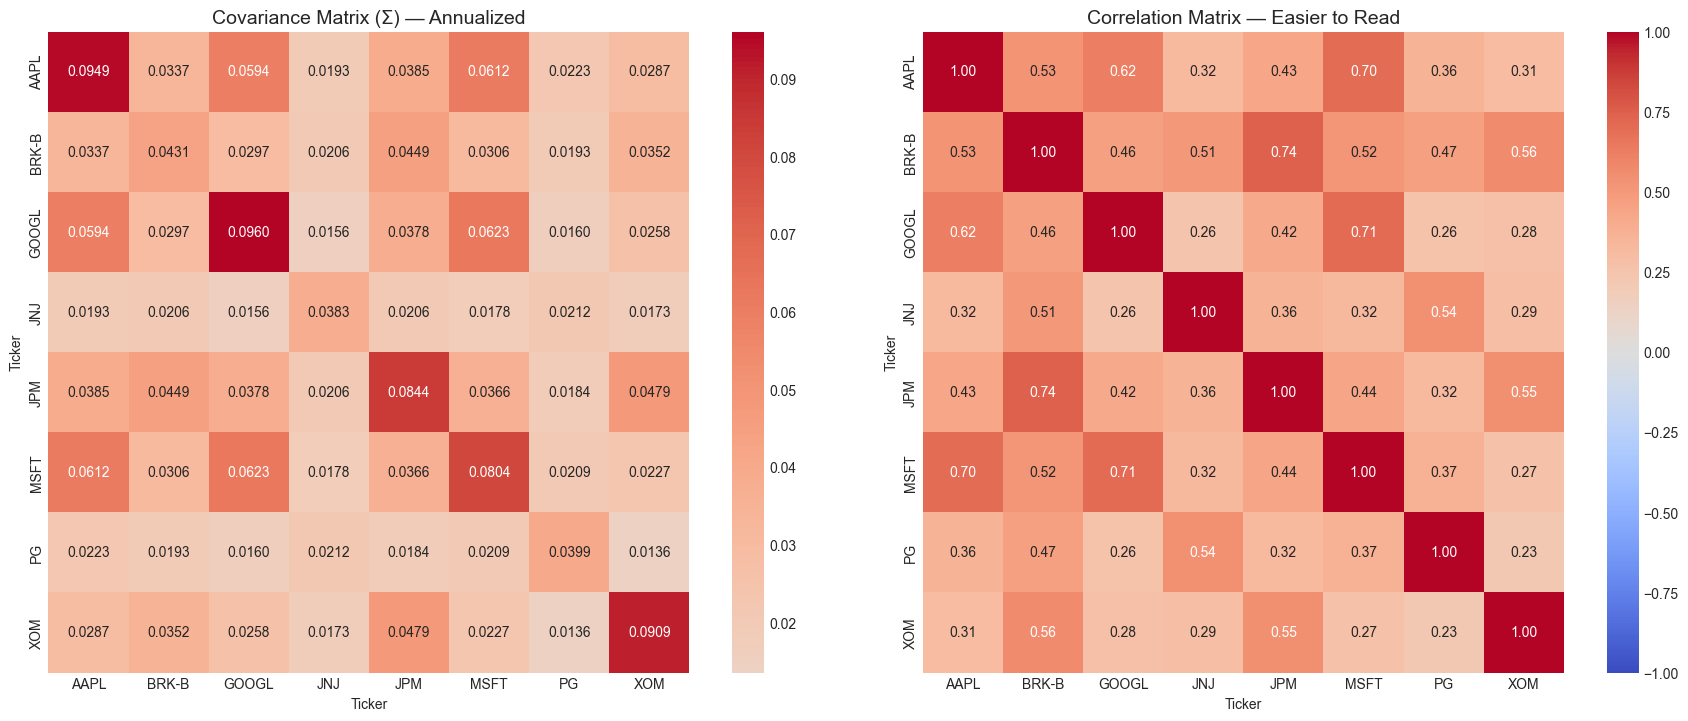

Left: Covariance — hard to interpret raw numbers.
Right: Correlation — scaled to [-1, 1], much clearer.

Key insight: stocks in the SAME sector (e.g., AAPL & MSFT) are highly correlated.
Stocks in DIFFERENT sectors (e.g., AAPL & XOM) are less correlated → better diversification.


In [136]:
# ===================================================================
# INPUT 2: COVARIANCE MATRIX
# ===================================================================
# The covariance matrix Σ captures:
#   - Diagonal: variance of each stock (how volatile it is)
#   - Off-diagonal: covariance between pairs (how they co-move)
#
# Annualized covariance = daily covariance × 252

cov_matrix = returns.cov() * 252  # Annualized covariance matrix

print(f'Covariance matrix shape: {cov_matrix.shape}')
print(f'It is a {len(TICKERS)}×{len(TICKERS)} matrix (one row/col per stock)\n')

# Visualize it as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Covariance matrix
sns.heatmap(cov_matrix, annot=True, fmt='.4f', cmap='coolwarm',
            center=0, ax=axes[0], square=True)
axes[0].set_title('Covariance Matrix (Σ) — Annualized', fontsize=14)

# Right: Correlation matrix (easier to interpret)
corr_matrix = returns.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[1], square=True, vmin=-1, vmax=1)
axes[1].set_title('Correlation Matrix — Easier to Read', fontsize=14)

plt.tight_layout()
plt.show()

print('Left: Covariance — hard to interpret raw numbers.')
print('Right: Correlation — scaled to [-1, 1], much clearer.')
print('\nKey insight: stocks in the SAME sector (e.g., AAPL & MSFT) are highly correlated.')
print('Stocks in DIFFERENT sectors (e.g., AAPL & XOM) are less correlated → better diversification.')

In [137]:
# ===================================================================
# UNDERSTANDING THE COVARIANCE MATRIX
# ===================================================================
# Let's break down what each part means.

print('DIAGONAL = Individual stock volatility (annualized std dev)')
print('=' * 60)
vols = np.sqrt(np.diag(cov_matrix))  # sqrt of diagonal = volatility
for i, ticker in enumerate(cov_matrix.columns):
    print(f'  {ticker:6s}: variance = {cov_matrix.iloc[i,i]:.4f}  →  volatility = {vols[i]*100:.1f}%')

print(f'\nOFF-DIAGONAL = How pairs of stocks co-move')
print('=' * 60)
# Show a few interesting pairs
pairs = [('AAPL', 'MSFT'), ('AAPL', 'XOM'), ('JPM', 'BRK-B'), ('XOM', 'JNJ')]
for t1, t2 in pairs:
    cov_val = cov_matrix.loc[t1, t2]
    corr_val = corr_matrix.loc[t1, t2]
    print(f'  {t1} & {t2}: cov = {cov_val:.4f}, corr = {corr_val:.2f}')

print(f'\nHigh correlation → they move together → less diversification benefit')
print(f'Low/negative correlation → they offset each other → more diversification')

DIAGONAL = Individual stock volatility (annualized std dev)
  AAPL  : variance = 0.0949  →  volatility = 30.8%
  BRK-B : variance = 0.0431  →  volatility = 20.8%
  GOOGL : variance = 0.0960  →  volatility = 31.0%
  JNJ   : variance = 0.0383  →  volatility = 19.6%
  JPM   : variance = 0.0844  →  volatility = 29.0%
  MSFT  : variance = 0.0804  →  volatility = 28.4%
  PG    : variance = 0.0399  →  volatility = 20.0%
  XOM   : variance = 0.0909  →  volatility = 30.2%

OFF-DIAGONAL = How pairs of stocks co-move
  AAPL & MSFT: cov = 0.0612, corr = 0.70
  AAPL & XOM: cov = 0.0287, corr = 0.31
  JPM & BRK-B: cov = 0.0449, corr = 0.74
  XOM & JNJ: cov = 0.0173, corr = 0.29

High correlation → they move together → less diversification benefit
Low/negative correlation → they offset each other → more diversification


### Quick Math Recap: How Portfolio Risk is Calculated

For a portfolio with weights **w** = [w₁, w₂, ..., wₙ]:

**Portfolio return:**
$$R_p = w_1 \mu_1 + w_2 \mu_2 + ... = \mathbf{w}^T \boldsymbol{\mu}$$

**Portfolio variance** (this is the key formula):
$$\sigma_p^2 = \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w} = \sum_i \sum_j w_i w_j \sigma_{ij}$$

Let's verify this with a concrete example.

In [138]:
# ===================================================================
# CONCRETE EXAMPLE: Portfolio risk calculation
# ===================================================================
# Equal-weight portfolio: put the same amount in each stock

n = len(TICKERS)
w_equal = np.array([1/n] * n)  # Equal weights

# Portfolio return: w'μ
port_return = w_equal @ mu.values  # @ is matrix multiplication

# Portfolio variance: w'Σw
port_variance = w_equal @ cov_matrix.values @ w_equal
port_volatility = np.sqrt(port_variance)

# Compare to average individual stock volatility
avg_stock_vol = vols.mean()

print('Equal-Weight Portfolio')
print('=' * 50)
print(f'Weights: {dict(zip(TICKERS, [f"{w:.1%}" for w in w_equal]))}')
print(f'\nPortfolio expected return:  {port_return*100:.1f}%')
print(f'Portfolio volatility:       {port_volatility*100:.1f}%')
print(f'Average stock volatility:   {avg_stock_vol*100:.1f}%')
print(f'\nDiversification benefit:    {(avg_stock_vol - port_volatility)*100:.1f}% lower volatility')
print(f'\nThis is the whole point of MVO — we got {(avg_stock_vol - port_volatility)/avg_stock_vol*100:.0f}% less risk')
print(f'just by spreading our money across {n} stocks.')

Equal-Weight Portfolio
Weights: {'AAPL': '12.5%', 'MSFT': '12.5%', 'JPM': '12.5%', 'XOM': '12.5%', 'JNJ': '12.5%', 'PG': '12.5%', 'GOOGL': '12.5%', 'BRK-B': '12.5%'}

Portfolio expected return:  18.9%
Portfolio volatility:       18.7%
Average stock volatility:   26.2%

Diversification benefit:    7.5% lower volatility

This is the whole point of MVO — we got 29% less risk
just by spreading our money across 8 stocks.


---
---
# Part 2: MVO From Scratch (numpy + scipy)
---
---

Now we solve the actual optimization problem. MVO has several formulations:

### Formulation 1: Minimize variance for a target return

```
minimize    w'Σw              (portfolio variance)
subject to  w'μ = target      (hit the return target)
            Σwᵢ = 1           (weights sum to 1, i.e., fully invested)
```

### Formulation 2: Maximize Sharpe ratio

```
maximize    (w'μ - rf) / √(w'Σw)    (return per unit of risk)
subject to  Σwᵢ = 1
```

### Formulation 3: Maximize return - λ × variance

```
maximize    w'μ - λ × w'Σw
subject to  Σwᵢ = 1
```

Where **λ** (lambda) is a "risk aversion" parameter:
- λ = 0 → "I don't care about risk, just maximize return"
- λ = ∞ → "I don't care about return, just minimize risk"

All three are equivalent — they trace out the same efficient frontier. Let's implement them.

In [139]:
# ===================================================================
# MVO FROM SCRATCH — Step by Step
# ===================================================================
# We use scipy.optimize.minimize, which is a general-purpose optimizer.
# We need to tell it:
#   1. What to minimize (objective function)
#   2. Starting point (initial guess for weights)
#   3. Constraints (weights sum to 1)
#   4. Bounds (optional: e.g., no shorting means 0 ≤ wᵢ ≤ 1)

mu_arr = mu.values         # Expected returns as numpy array
cov_arr = cov_matrix.values  # Covariance matrix as numpy array
n_assets = len(TICKERS)

# --- Helper functions ---

def portfolio_return(w):
    """Portfolio expected return: w'μ"""
    return w @ mu_arr

def portfolio_volatility(w):
    """Portfolio volatility: sqrt(w'Σw)"""
    return np.sqrt(w @ cov_arr @ w)

def portfolio_sharpe(w, rf=0.04):
    """Sharpe ratio: (return - risk_free) / volatility"""
    return (portfolio_return(w) - rf) / portfolio_volatility(w)

print('Helper functions defined.')
print(f'  portfolio_return(w)     → w\'μ')
print(f'  portfolio_volatility(w) → √(w\'Σw)')
print(f'  portfolio_sharpe(w)     → (w\'μ - rf) / √(w\'Σw)')

Helper functions defined.
  portfolio_return(w)     → w'μ
  portfolio_volatility(w) → √(w'Σw)
  portfolio_sharpe(w)     → (w'μ - rf) / √(w'Σw)


In [140]:
# ===================================================================
# SOLVE 1: Minimum Variance Portfolio
# ===================================================================
# The portfolio with the LOWEST possible risk, regardless of return.
# This is the leftmost point on the efficient frontier.

# Objective: minimize portfolio variance
def neg_sharpe(w):
    return -portfolio_sharpe(w)

def min_var_objective(w):
    return w @ cov_arr @ w  # Portfolio variance

# Constraints
constraints = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # Weights sum to 1
]

# Bounds: no shorting (each weight between 0 and 1)
bounds = tuple((0, 1) for _ in range(n_assets))

# Initial guess: equal weights
w0 = np.array([1/n_assets] * n_assets)

# Solve!
result_minvar = minimize(
    min_var_objective,  # What to minimize
    w0,                 # Starting point
    method='SLSQP',     # Sequential Least Squares Programming (handles constraints)
    bounds=bounds,
    constraints=constraints
)

w_minvar = result_minvar.x

print('MINIMUM VARIANCE PORTFOLIO')
print('=' * 50)
print('Weights:')
for i, ticker in enumerate(TICKERS):
    if w_minvar[i] > 0.001:  # Only show non-zero weights
        print(f'  {ticker:6s}: {w_minvar[i]*100:5.1f}%')
print(f'\nExpected return:  {portfolio_return(w_minvar)*100:.1f}%')
print(f'Volatility:       {portfolio_volatility(w_minvar)*100:.1f}%')
print(f'Sharpe ratio:     {portfolio_sharpe(w_minvar):.3f}')
print(f'\nNotice: the optimizer loads up on LOW-VOLATILITY, LOW-CORRELATION stocks.')

MINIMUM VARIANCE PORTFOLIO
Weights:
  MSFT  :  15.9%
  JPM   :   7.6%
  XOM   :  33.4%
  PG    :   2.1%
  GOOGL :  32.8%
  BRK-B :   8.2%

Expected return:  12.6%
Volatility:       16.1%
Sharpe ratio:     0.536

Notice: the optimizer loads up on LOW-VOLATILITY, LOW-CORRELATION stocks.


In [141]:
# ===================================================================
# SOLVE 2: Maximum Sharpe Ratio Portfolio (Tangency Portfolio)
# ===================================================================
# The portfolio with the best return PER UNIT OF RISK.
# This is the portfolio where a line from the risk-free rate
# is tangent to the efficient frontier.

result_maxsharpe = minimize(
    neg_sharpe,         # Minimize negative Sharpe = maximize Sharpe
    w0,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

w_maxsharpe = result_maxsharpe.x

print('MAXIMUM SHARPE RATIO PORTFOLIO (Tangency Portfolio)')
print('=' * 50)
print('Weights:')
for i, ticker in enumerate(TICKERS):
    if w_maxsharpe[i] > 0.001:
        print(f'  {ticker:6s}: {w_maxsharpe[i]*100:5.1f}%')
print(f'\nExpected return:  {portfolio_return(w_maxsharpe)*100:.1f}%')
print(f'Volatility:       {portfolio_volatility(w_maxsharpe)*100:.1f}%')
print(f'Sharpe ratio:     {portfolio_sharpe(w_maxsharpe):.3f}')

MAXIMUM SHARPE RATIO PORTFOLIO (Tangency Portfolio)
Weights:
  AAPL  :  33.2%
  JPM   :  19.0%
  JNJ   :  17.8%
  PG    :  30.0%

Expected return:  26.4%
Volatility:       24.8%
Sharpe ratio:     0.903


In [142]:
# ===================================================================
# SOLVE 3: Target Return Portfolio
# ===================================================================
# "I want 15% annual return — what weights minimize my risk?"

def min_var_for_target(target_return):
    """Find minimum-variance portfolio that achieves a target return."""
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},                # Weights sum to 1
        {'type': 'eq', 'fun': lambda w: portfolio_return(w) - target_return}  # Hit target return
    ]
    result = minimize(min_var_objective, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints)
    return result.x

# Example: target 15% return
target = 0.15
w_target = min_var_for_target(target)

print(f'PORTFOLIO TARGETING {target*100:.0f}% RETURN')
print('=' * 50)
print('Weights:')
for i, ticker in enumerate(TICKERS):
    if w_target[i] > 0.001:
        print(f'  {ticker:6s}: {w_target[i]*100:5.1f}%')
print(f'\nExpected return:  {portfolio_return(w_target)*100:.1f}%')
print(f'Volatility:       {portfolio_volatility(w_target)*100:.1f}%')
print(f'Sharpe ratio:     {portfolio_sharpe(w_target):.3f}')
print(f'\nCompare this to the max-Sharpe portfolio above.')
print(f'Higher target return → more concentrated in high-return (risky) stocks.')

PORTFOLIO TARGETING 15% RETURN
Weights:
  AAPL  :   3.7%
  MSFT  :  12.5%
  JPM   :  11.0%
  XOM   :  27.5%
  JNJ   :   0.9%
  PG    :   9.0%
  GOOGL :  27.4%
  BRK-B :   8.0%

Expected return:  15.0%
Volatility:       16.5%
Sharpe ratio:     0.667

Compare this to the max-Sharpe portfolio above.
Higher target return → more concentrated in high-return (risky) stocks.


---
---
# Part 3: The Efficient Frontier
---
---

The efficient frontier is the set of ALL optimal portfolios — one for each possible target return. Every point on the frontier represents the minimum risk you can achieve for that level of return.

```
Return ↑
       |          * Max Sharpe
       |        /
       |      /    ← Efficient Frontier (upper curve)
       |    /
       |  * Min Variance
       |    \
       |      \   ← Inefficient (same risk, less return)
       |        \
       +──────────────→ Risk (Volatility)
```

Portfolios BELOW the minimum-variance point are "inefficient" — you could get more return for the same risk by moving up the curve.

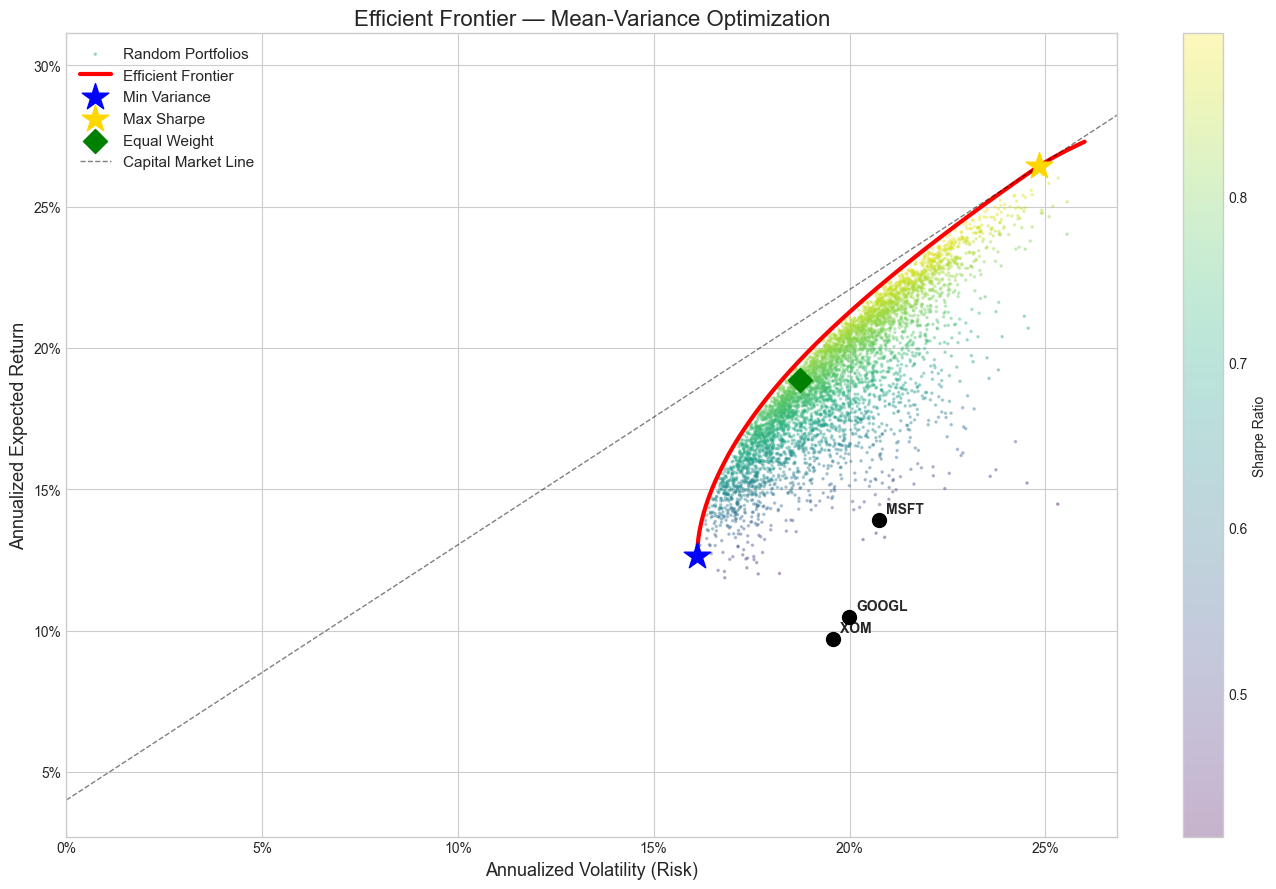

Each colored dot = a random portfolio (color = Sharpe ratio).
Red line = efficient frontier (best possible return for each risk level).
No random portfolio beats the frontier — that is the point of MVO.

Capital Market Line: if you can borrow/lend at the risk-free rate,
you mix the tangency portfolio with cash to get any point on this line.


In [143]:
# ===================================================================
# PLOT THE EFFICIENT FRONTIER
# ===================================================================
# Strategy: solve for minimum-variance portfolio at many target returns,
# then plot all of them.

# Range of target returns to try
min_ret = portfolio_return(w_minvar)
max_ret = mu.max()  # Can't exceed the best individual stock
target_returns = np.linspace(min_ret, max_ret * 0.95, 50)

frontier_vols = []
frontier_rets = []
frontier_weights = []

for target in target_returns:
    try:
        w = min_var_for_target(target)
        vol = portfolio_volatility(w)
        ret = portfolio_return(w)
        # Only keep if the optimizer actually hit the target (within tolerance)
        if abs(ret - target) < 0.01:
            frontier_vols.append(vol)
            frontier_rets.append(ret)
            frontier_weights.append(w)
    except Exception:
        pass

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 9))

# 1. Random portfolios (for context)
np.random.seed(42)
n_random = 5000
random_rets = []
random_vols = []
random_sharpes = []
for _ in range(n_random):
    w_rand = np.random.dirichlet(np.ones(n_assets))  # Random weights that sum to 1
    random_rets.append(portfolio_return(w_rand))
    random_vols.append(portfolio_volatility(w_rand))
    random_sharpes.append(portfolio_sharpe(w_rand))

scatter = ax.scatter(random_vols, random_rets, c=random_sharpes, cmap='viridis',
                     marker='.', alpha=0.3, s=10, label='Random Portfolios')
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# 2. Efficient frontier
ax.plot(frontier_vols, frontier_rets, 'r-', linewidth=3, label='Efficient Frontier')

# 3. Special portfolios
ax.scatter(portfolio_volatility(w_minvar), portfolio_return(w_minvar),
           marker='*', s=400, c='blue', zorder=5, label='Min Variance')
ax.scatter(portfolio_volatility(w_maxsharpe), portfolio_return(w_maxsharpe),
           marker='*', s=400, c='gold', zorder=5, label='Max Sharpe')
ax.scatter(portfolio_volatility(w_equal), portfolio_return(w_equal),
           marker='D', s=150, c='green', zorder=5, label='Equal Weight')

# 4. Individual stocks
for i, ticker in enumerate(TICKERS):
    ax.scatter(vols[i], mu_arr[i], marker='o', s=100, c='black', zorder=5)
    ax.annotate(ticker, (vols[i], mu_arr[i]), fontsize=10, fontweight='bold',
                xytext=(5, 5), textcoords='offset points')

# 5. Capital Market Line (from risk-free rate through tangency portfolio)
rf = 0.04
cml_x = np.linspace(0, max(frontier_vols) * 1.1, 100)
cml_slope = portfolio_sharpe(w_maxsharpe)
cml_y = rf + cml_slope * cml_x
ax.plot(cml_x, cml_y, 'k--', alpha=0.5, linewidth=1, label='Capital Market Line')

ax.set_xlabel('Annualized Volatility (Risk)', fontsize=13)
ax.set_ylabel('Annualized Expected Return', fontsize=13)
ax.set_title('Efficient Frontier — Mean-Variance Optimization', fontsize=16)
ax.legend(fontsize=11, loc='upper left')
ax.set_xlim(0, max(random_vols) * 1.05)

# Format axes as percentages
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

print('Each colored dot = a random portfolio (color = Sharpe ratio).')
print('Red line = efficient frontier (best possible return for each risk level).')
print('No random portfolio beats the frontier — that is the point of MVO.')
print('\nCapital Market Line: if you can borrow/lend at the risk-free rate,')
print('you mix the tangency portfolio with cash to get any point on this line.')

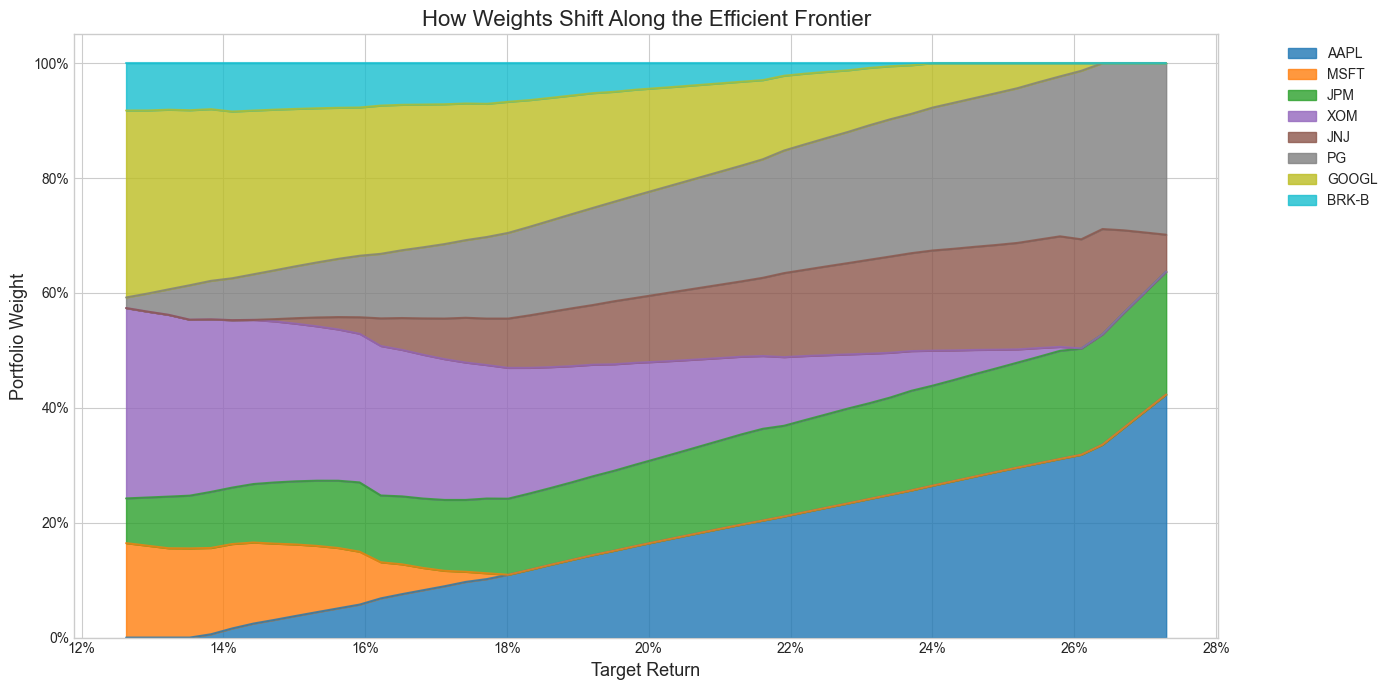

Left side (low target return): diversified across many stocks.
Right side (high target return): concentrated in the highest-return stocks.

This is the risk-return tradeoff made visible.


In [144]:
# ===================================================================
# HOW WEIGHTS CHANGE ALONG THE FRONTIER
# ===================================================================
# As you move from left (low risk) to right (high return), which stocks
# get more or less weight?

if len(frontier_weights) > 0:
    weights_df = pd.DataFrame(frontier_weights, columns=TICKERS)
    weights_df['Target Return'] = frontier_rets[:len(weights_df)]

    fig, ax = plt.subplots(figsize=(14, 7))
    weights_df.set_index('Target Return')[TICKERS].plot.area(
        ax=ax, colormap='tab10', alpha=0.8
    )
    ax.set_xlabel('Target Return', fontsize=13)
    ax.set_ylabel('Portfolio Weight', fontsize=13)
    ax.set_title('How Weights Shift Along the Efficient Frontier', fontsize=16)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    plt.tight_layout()
    plt.show()

    print('Left side (low target return): diversified across many stocks.')
    print('Right side (high target return): concentrated in the highest-return stocks.')
    print('\nThis is the risk-return tradeoff made visible.')

---
---
# Part 4: Adding Real-World Constraints
---
---

Textbook MVO is unconstrained (or just has "weights sum to 1"). Real portfolios have constraints:

| Constraint | Why | Code |
|-----------|-----|------|
| No short selling | Many funds can't short | `0 ≤ wᵢ ≤ 1` |
| Position limits | Don't put >25% in one stock | `wᵢ ≤ 0.25` |
| Sector limits | Don't put >40% in tech | `Σ w_tech ≤ 0.40` |
| Minimum holding | If you hold it, hold at least 2% | `wᵢ = 0 or wᵢ ≥ 0.02` |
| Turnover limit | Don't trade too much (costs) | `Σ|wᵢ - wᵢ_old| ≤ T` |

Let's add these one by one.

Flexible MVO solver defined. Let's compare different constraint sets.

Unconstrained (no short)
  Return: 26.4%  |  Vol: 24.8%  |  Sharpe: 0.903
    AAPL: +33.2%
    JPM: +19.0%
    JNJ: +17.8%
    PG: +30.0%

Max 25% per stock
  Return: 25.5%  |  Vol: 24.0%  |  Sharpe: 0.898
    AAPL: +25.0%
    JPM: +25.0%
    JNJ: +22.1%
    PG: +25.0%
    GOOGL: +2.9%

Max 25% per stock + 40% per sector
  Return: 25.5%  |  Vol: 24.0%  |  Sharpe: 0.898
    AAPL: +25.0%
    JPM: +25.0%
    JNJ: +22.1%
    PG: +25.0%
    GOOGL: +2.9%

Allow shorting
  Return: 30.9%  |  Vol: 29.2%  |  Sharpe: 0.923
    AAPL: +43.2%
    MSFT: -47.5%
    JPM: +22.5%
    XOM: +0.9%
    JNJ: +40.8%
    PG: +38.4%
    GOOGL: +1.6%
    BRK-B: +0.2%



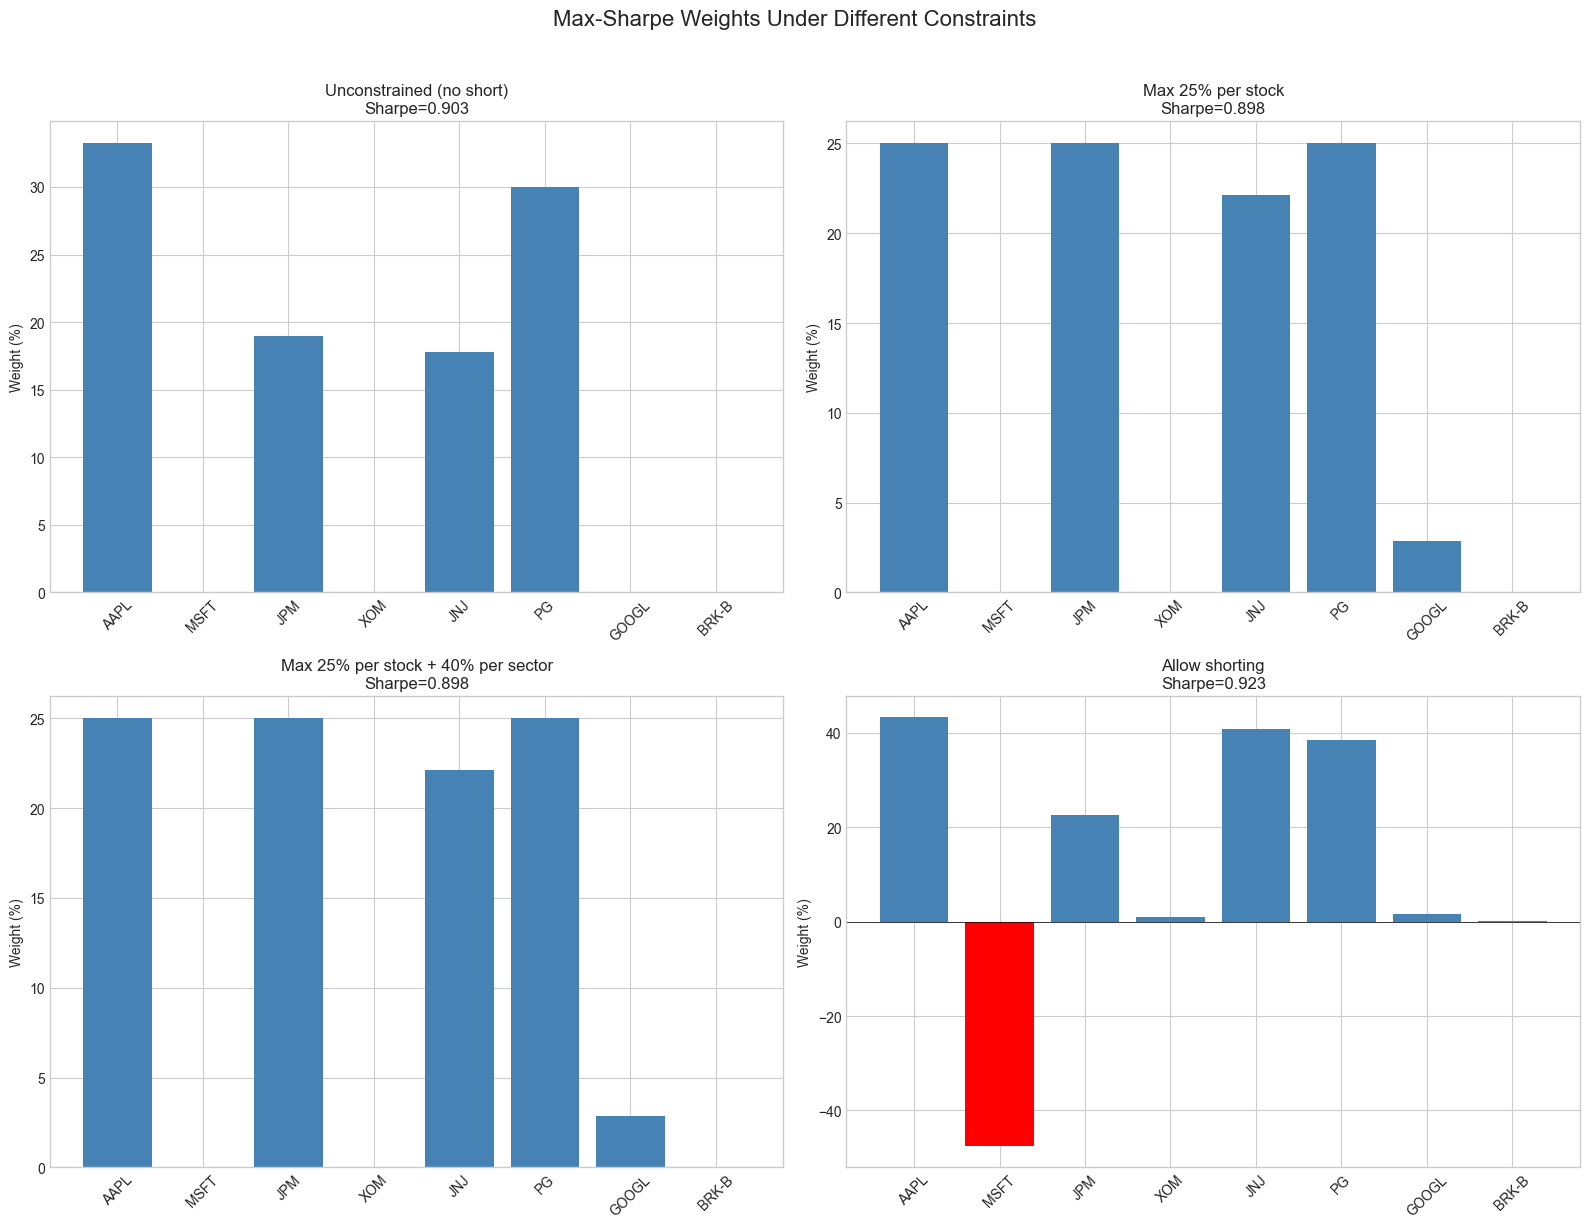

Notice: more constraints → lower Sharpe ratio (less freedom to optimize).
But constraints prevent the crazy concentrated bets that blow up in practice.


In [145]:
# ===================================================================
# CONSTRAINED MVO — Position Limits & Sector Constraints
# ===================================================================

def solve_mvo(mu_arr, cov_arr, tickers, sector_map=None,
              max_weight=1.0, max_sector_weight=1.0,
              allow_shorting=False, target_return=None):
    """
    Solve MVO with realistic constraints.
    
    Parameters:
    -----------
    mu_arr : expected returns vector
    cov_arr : covariance matrix
    tickers : list of ticker names
    sector_map : dict mapping ticker → sector
    max_weight : max allocation to any single stock
    max_sector_weight : max allocation to any sector
    allow_shorting : whether to allow negative weights
    target_return : if set, minimize variance for this return; otherwise maximize Sharpe
    """
    n = len(tickers)
    w0 = np.array([1/n] * n)
    
    # Bounds
    if allow_shorting:
        bounds = tuple((-1, 1) for _ in range(n))
    else:
        bounds = tuple((0, max_weight) for _ in range(n))
    
    # Constraints
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    
    if target_return is not None:
        constraints.append(
            {'type': 'eq', 'fun': lambda w: w @ mu_arr - target_return}
        )
    
    # Sector constraints
    if sector_map is not None and max_sector_weight < 1.0:
        sectors = set(sector_map.values())
        for sector in sectors:
            idx = [i for i, t in enumerate(tickers) if sector_map.get(t) == sector]
            constraints.append(
                {'type': 'ineq', 'fun': lambda w, idx=idx: max_sector_weight - sum(w[i] for i in idx)}
            )
    
    # Objective
    if target_return is not None:
        objective = lambda w: w @ cov_arr @ w  # Minimize variance
    else:
        rf = 0.04
        objective = lambda w: -(w @ mu_arr - rf) / np.sqrt(w @ cov_arr @ w)  # Max Sharpe
    
    result = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
    return result.x

print('Flexible MVO solver defined. Let\'s compare different constraint sets.\n')

# --- Compare different constraint sets ---
scenarios = {
    'Unconstrained (no short)': dict(max_weight=1.0, max_sector_weight=1.0),
    'Max 25% per stock': dict(max_weight=0.25, max_sector_weight=1.0),
    'Max 25% per stock + 40% per sector': dict(max_weight=0.25, max_sector_weight=0.40),
    'Allow shorting': dict(max_weight=1.0, max_sector_weight=1.0, allow_shorting=True),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, params) in enumerate(scenarios.items()):
    w = solve_mvo(mu_arr, cov_arr, TICKERS, SECTOR_MAP, **params)
    ret = portfolio_return(w)
    vol = portfolio_volatility(w)
    sr = portfolio_sharpe(w)
    
    print(f'{name}')
    print(f'  Return: {ret*100:.1f}%  |  Vol: {vol*100:.1f}%  |  Sharpe: {sr:.3f}')
    for i, t in enumerate(TICKERS):
        if abs(w[i]) > 0.001:
            print(f'    {t}: {w[i]*100:+.1f}%')
    print()
    
    # Bar chart of weights
    colors = ['red' if wi < 0 else 'steelblue' for wi in w]
    axes[idx].bar(TICKERS, w * 100, color=colors)
    axes[idx].set_title(f'{name}\nSharpe={sr:.3f}', fontsize=12)
    axes[idx].set_ylabel('Weight (%)')
    axes[idx].axhline(y=0, color='black', linewidth=0.5)
    axes[idx].tick_params(axis='x', rotation=45)

plt.suptitle('Max-Sharpe Weights Under Different Constraints', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('Notice: more constraints → lower Sharpe ratio (less freedom to optimize).')
print('But constraints prevent the crazy concentrated bets that blow up in practice.')

---
---
# Part 5: Using PyPortfolioOpt (The Industry Library)
---
---

In practice, you don't write the optimizer from scratch. **PyPortfolioOpt** (`pypfopt`) is the standard Python library for portfolio optimization. It handles:

- Multiple return estimation methods
- Multiple risk models (covariance estimators)
- Efficient frontier with constraints
- Black-Litterman model
- Discrete allocation (convert weights → actual share counts)

```
Your code (from scratch)              PyPortfolioOpt
─────────────────────────             ─────────────────
~50 lines of scipy                    ~5 lines
Manual constraint setup               Built-in constraints
Only sample covariance                Shrinkage, Ledoit-Wolf, etc.
Only historical mean returns          CAPM, Black-Litterman, etc.
```

In [146]:
# ===================================================================
# PyPortfolioOpt — Basic Usage
# ===================================================================

from pypfopt import expected_returns, risk_models
from pypfopt import EfficientFrontier
from pypfopt import plotting
from pypfopt.discrete_allocation import DiscreteAllocation

# Step 1: Estimate expected returns
mu_pypfopt = expected_returns.mean_historical_return(prices)  # Same as what we did manually

# Step 2: Estimate covariance matrix
cov_pypfopt = risk_models.sample_cov(prices)  # Same as what we did manually

print('Expected returns (pypfopt):')
print(mu_pypfopt.round(4))
print(f'\nCovariance matrix shape: {cov_pypfopt.shape}')

Expected returns (pypfopt):
Ticker
AAPL     0.2711
BRK-B    0.1248
GOOGL    0.2492
JNJ      0.0808
JPM      0.1795
MSFT     0.2563
PG       0.0884
XOM      0.0943
dtype: float64

Covariance matrix shape: (8, 8)


In [147]:
# ===================================================================
# Maximum Sharpe Portfolio — 3 lines of code
# ===================================================================

ef = EfficientFrontier(mu_pypfopt, cov_pypfopt)
ef.max_sharpe(risk_free_rate=0.04)
weights_maxsharpe = ef.clean_weights()  # Rounds tiny weights to 0

print('MAX SHARPE PORTFOLIO (PyPortfolioOpt)')
print('=' * 50)
for ticker, weight in weights_maxsharpe.items():
    if weight > 0:
        print(f'  {ticker:6s}: {weight*100:5.1f}%')

perf = ef.portfolio_performance(verbose=True, risk_free_rate=0.04)

MAX SHARPE PORTFOLIO (PyPortfolioOpt)
  AAPL  :  35.8%
  GOOGL :  15.4%
  JPM   :  10.7%
  MSFT  :  38.1%
Expected annual return: 25.2%
Annual volatility: 25.5%
Sharpe Ratio: 0.83


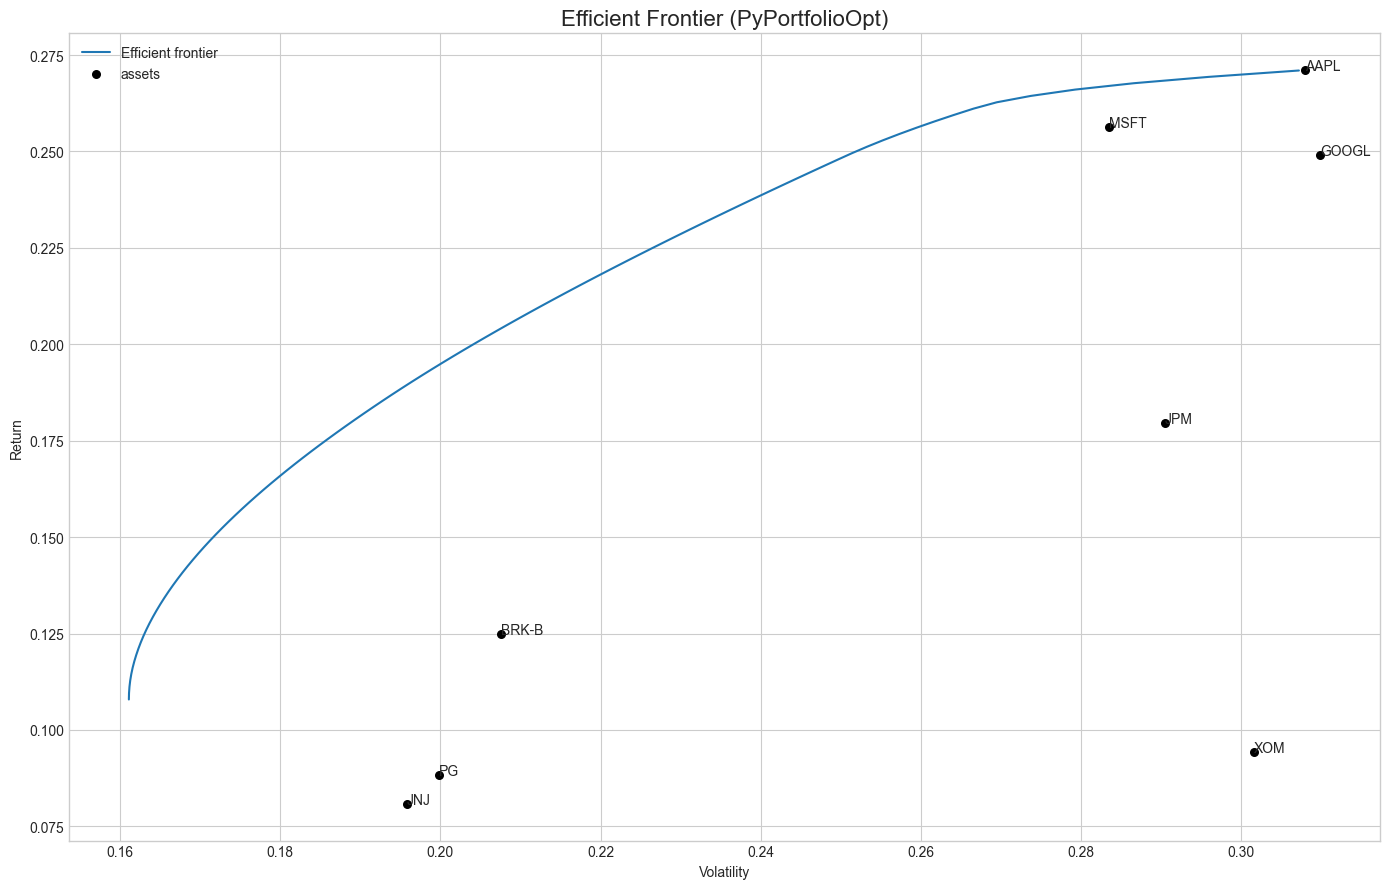

In [148]:
# ===================================================================
# PyPortfolioOpt — Plot the Efficient Frontier
# ===================================================================

fig, ax = plt.subplots(figsize=(14, 9))

# Use pypfopt's built-in frontier plotting
ef_plot = EfficientFrontier(mu_pypfopt, cov_pypfopt)

# Plot the frontier
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True,
                                 show_tickers=True)

ax.set_title('Efficient Frontier (PyPortfolioOpt)', fontsize=16)

plt.tight_layout()
plt.show()

In [149]:
# ===================================================================
# Efficient Return — Target a specific return
# ===================================================================

ef_target = EfficientFrontier(mu_pypfopt, cov_pypfopt)
ef_target.efficient_return(target_return=0.15)  # Target 15%
weights_target = ef_target.clean_weights()

print('PORTFOLIO TARGETING 15% RETURN (PyPortfolioOpt)')
print('=' * 50)
for ticker, weight in weights_target.items():
    if weight > 0:
        print(f'  {ticker:6s}: {weight*100:5.1f}%')

ef_target.portfolio_performance(verbose=True, risk_free_rate=0.04)

PORTFOLIO TARGETING 15% RETURN (PyPortfolioOpt)
  AAPL  :   8.4%
  BRK-B :   9.1%
  GOOGL :  11.0%
  JNJ   :  25.1%
  JPM   :   4.4%
  MSFT  :  13.7%
  PG    :  24.2%
  XOM   :   4.2%
Expected annual return: 15.0%
Annual volatility: 17.2%
Sharpe Ratio: 0.64


(np.float64(0.14999999999999997),
 np.float64(0.17163879186085168),
 np.float64(0.6408807636514794))

In [150]:
# ===================================================================
# ADDING CONSTRAINTS in PyPortfolioOpt
# ===================================================================

# --- Constraint 1: Position limits ---
ef_c1 = EfficientFrontier(mu_pypfopt, cov_pypfopt,
                          weight_bounds=(0.02, 0.25))  # Min 2%, max 25% per stock
ef_c1.max_sharpe(risk_free_rate=0.04)
w_c1 = ef_c1.clean_weights()

print('WITH POSITION LIMITS (2% ≤ w ≤ 25%)')
print('=' * 50)
for ticker, weight in w_c1.items():
    if weight > 0:
        print(f'  {ticker:6s}: {weight*100:5.1f}%')
ef_c1.portfolio_performance(verbose=True, risk_free_rate=0.04)

print()

# --- Constraint 2: Sector constraints ---
sector_mapper = SECTOR_MAP
sector_lower = {}   # No minimum per sector
sector_upper = {'Tech': 0.40, 'Finance': 0.30, 'Energy': 0.20,
                'Healthcare': 0.20, 'Consumer': 0.20}

ef_c2 = EfficientFrontier(mu_pypfopt, cov_pypfopt)
ef_c2.add_sector_constraints(sector_mapper, sector_lower, sector_upper)
ef_c2.max_sharpe(risk_free_rate=0.04)
w_c2 = ef_c2.clean_weights()

print('WITH SECTOR CONSTRAINTS (Tech ≤ 40%, Finance ≤ 30%, others ≤ 20%)')
print('=' * 50)
for ticker, weight in w_c2.items():
    if weight > 0:
        print(f'  {ticker:6s} ({sector_mapper[ticker]:10s}): {weight*100:5.1f}%')
ef_c2.portfolio_performance(verbose=True, risk_free_rate=0.04)

WITH POSITION LIMITS (2% ≤ w ≤ 25%)
  AAPL  :  25.0%
  BRK-B :   2.0%
  GOOGL :  25.0%
  JNJ   :   2.0%
  JPM   :  17.0%
  MSFT  :  25.0%
  PG    :   2.0%
  XOM   :   2.0%
Expected annual return: 23.2%
Annual volatility: 23.6%
Sharpe Ratio: 0.81

WITH SECTOR CONSTRAINTS (Tech ≤ 40%, Finance ≤ 30%, others ≤ 20%)
  AAPL   (Tech      ):  18.3%
  GOOGL  (Tech      ):   6.0%
  JNJ    (Healthcare):  11.1%
  JPM    (Finance   ):  30.0%
  MSFT   (Tech      ):  15.6%
  PG     (Consumer  ):  18.9%
Expected annual return: 18.4%
Annual volatility: 19.8%
Sharpe Ratio: 0.73


(np.float64(0.18432867163094763),
 np.float64(0.19781994448062784),
 np.float64(0.7295961588194737))

In [151]:
# ===================================================================
# DISCRETE ALLOCATION — Convert weights to actual shares
# ===================================================================
# MVO gives you weights like 23.5%. But you can't buy 0.235 of a share
# (well, some brokers allow fractional shares, but many don't).
# DiscreteAllocation converts weights → integer share counts.

latest_prices = prices.iloc[-1]

# Use the max-Sharpe weights
da = DiscreteAllocation(weights_maxsharpe, latest_prices, total_portfolio_value=100_000)
allocation, leftover = da.greedy_portfolio()

print('DISCRETE ALLOCATION — $100,000 Portfolio')
print('=' * 50)
print(f'{"Stock":<8} {"Shares":<8} {"Price":>10} {"Value":>12} {"Weight":>8}')
print('-' * 50)
total_invested = 0
for ticker, shares in allocation.items():
    price = latest_prices[ticker]
    value = shares * price
    total_invested += value
    print(f'{ticker:<8} {shares:<8} ${price:>9.2f} ${value:>11.2f} {value/100000*100:>7.1f}%')

print(f'\nTotal invested: ${total_invested:,.2f}')
print(f'Cash leftover:  ${leftover:,.2f}')
print(f'\nThis is what you would actually go and BUY.')

DISCRETE ALLOCATION — $100,000 Portfolio
Stock    Shares        Price        Value   Weight
--------------------------------------------------
MSFT     78       $   486.37 $   37936.85    37.9%
AAPL     131      $   272.82 $   35740.04    35.7%
GOOGL    49       $   313.63 $   15367.83    15.4%
JPM      34       $   321.97 $   10946.90    10.9%

Total invested: $99,991.62
Cash leftover:  $8.38

This is what you would actually go and BUY.


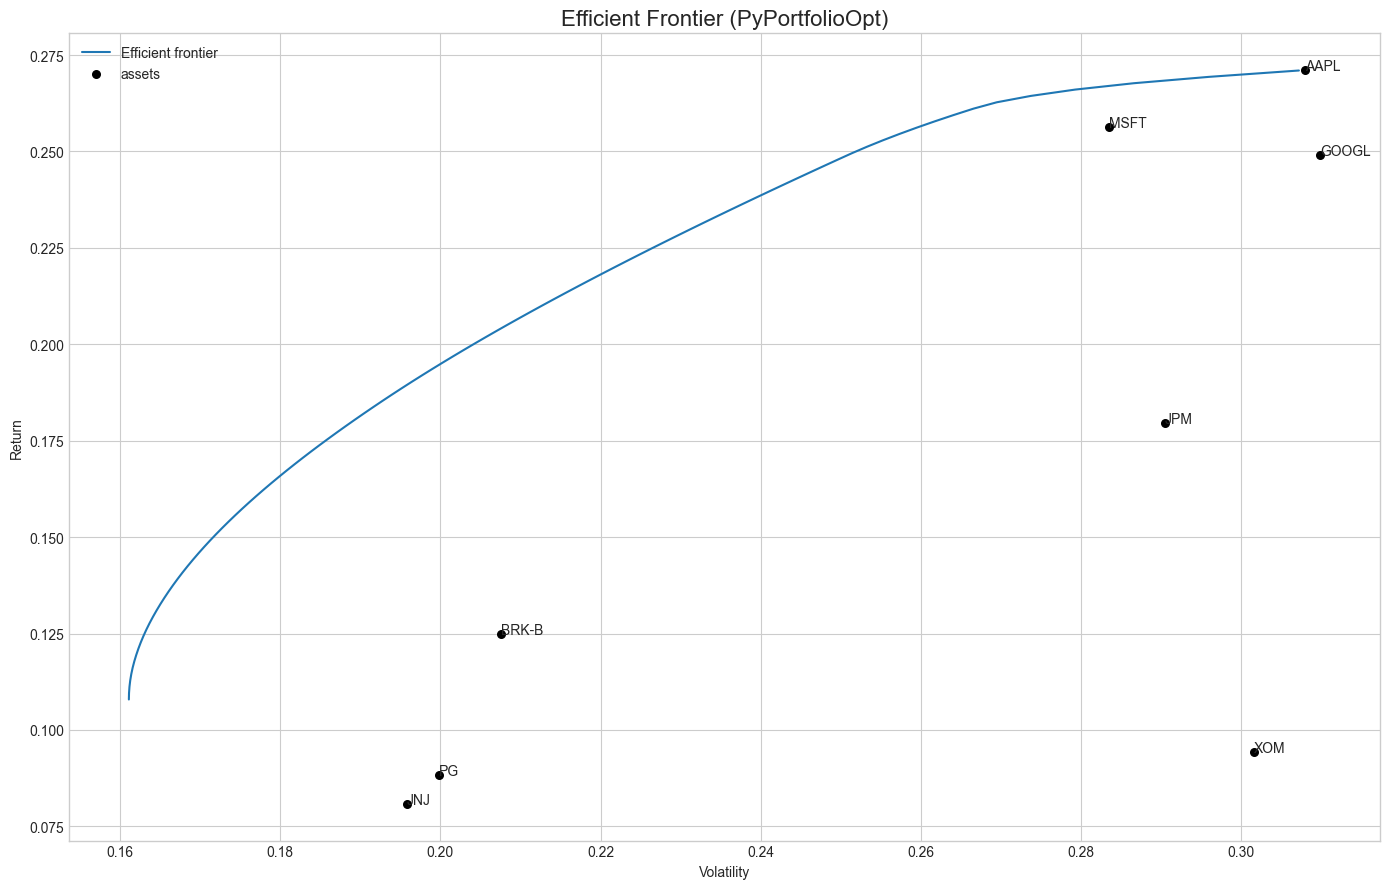

In [152]:
# ===================================================================
# PyPortfolioOpt — Plot the Efficient Frontier
# ===================================================================

fig, ax = plt.subplots(figsize=(14, 9))

# Use pypfopt's built-in frontier plotting
ef_plot = EfficientFrontier(mu_pypfopt, cov_pypfopt)

# Plot the frontier
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True,
                                 show_tickers=True)

ax.set_title('Efficient Frontier (PyPortfolioOpt)', fontsize=16)

plt.tight_layout()
plt.show()

---
---
# Part 6: Why Textbook MVO Fails (and What Practitioners Actually Do)
---
---

Here's the dirty secret of MVO: **it doesn't work well out of the box.** The theory is elegant, but the practice is messy.

### The Core Problem: Estimation Error

MVO takes your inputs (μ, Σ) and treats them as **exact truth**. But they're just estimates from noisy historical data. Small errors in inputs → wildly different weights.

```
Textbook MVO assumes:          Reality:
─────────────────────          ────────────────────────
μ and Σ are known exactly      μ and Σ are noisy estimates
Past returns predict future    They don't (much)
Covariance is stable           It changes in crises
```

### The Symptoms

1. **Extreme weights** — MVO loves to put 80% in one stock because its historical return was 0.1% higher
2. **Unstable weights** — add one month of data and weights flip completely
3. **"Error maximization"** — MVO systematically overweights assets whose returns are overestimated (by random noise) and underweights the rest. It amplifies your estimation errors.

### The Fixes

| Problem | Fix | How |
|---------|-----|-----|
| Noisy expected returns | Shrink toward equal returns | Don't trust historical mean blindly |
| Noisy covariance matrix | Shrinkage estimators (Ledoit-Wolf) | Pull extreme values toward a structured estimate |
| Returns are unpredictable | Black-Litterman model | Start from market equilibrium, add your views |
| Extreme weights | Constraints + regularization | Force diversification |

Let's see each fix in action.

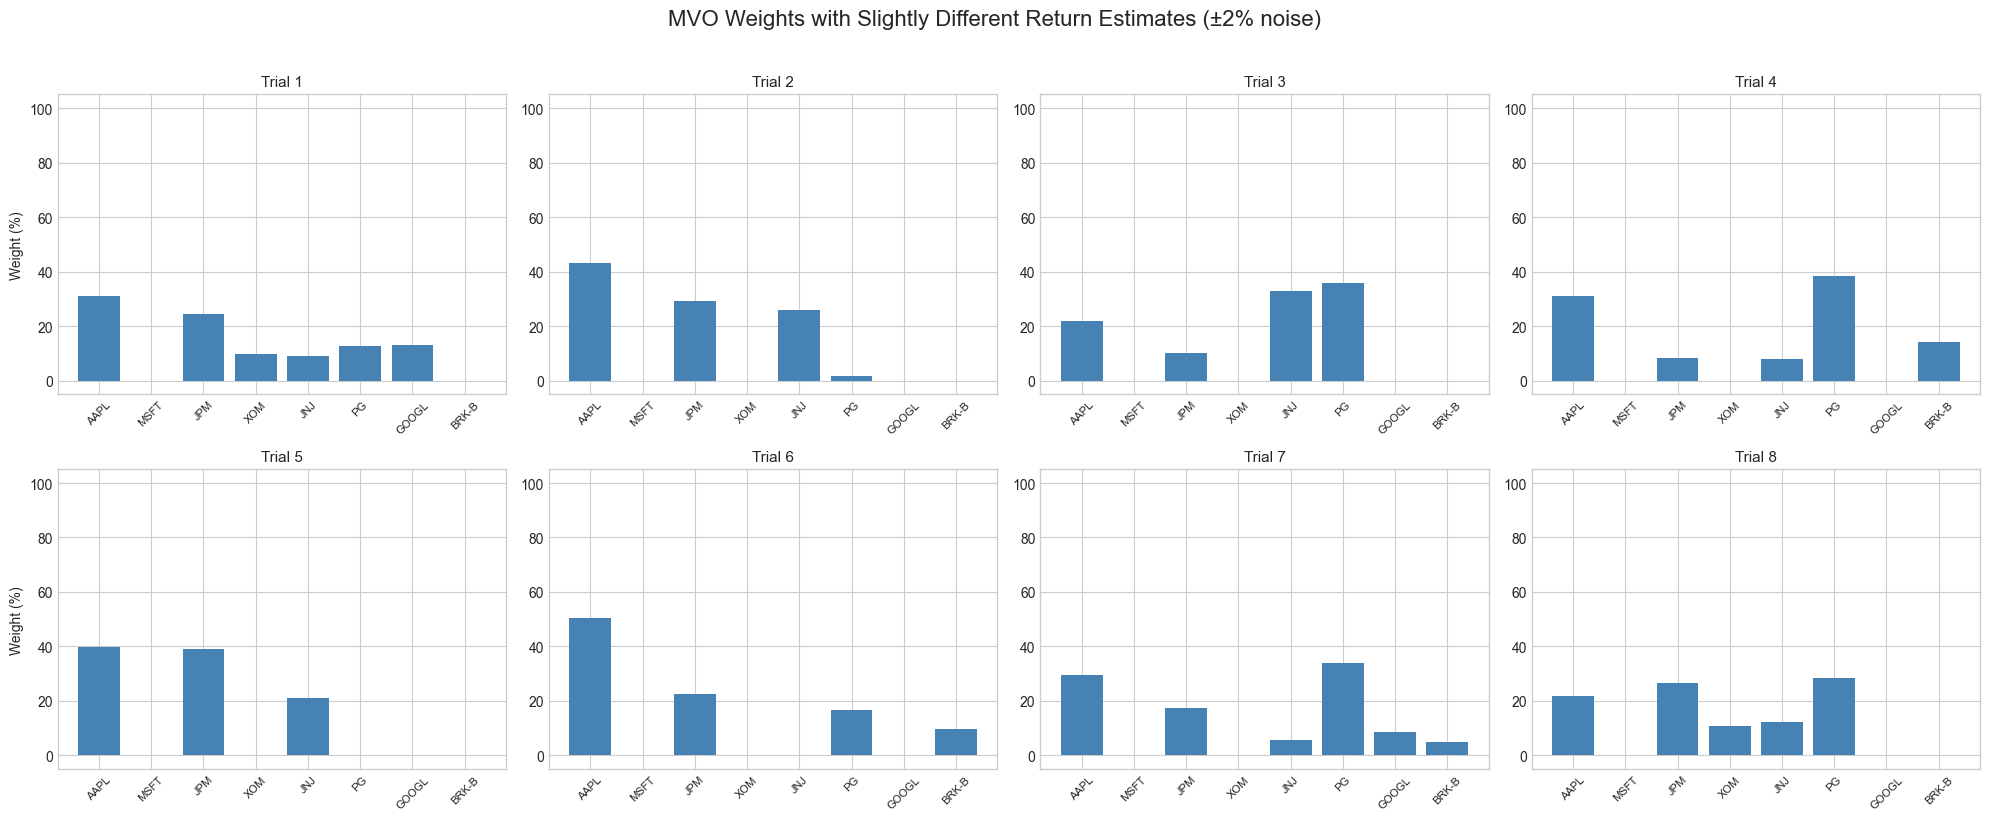

Each panel uses the SAME covariance matrix but slightly different expected returns.
Notice how the weights are completely different each time!
This is the "error maximization" problem — MVO amplifies noise in your inputs.


In [153]:
# ===================================================================
# DEMONSTRATION: MVO is sensitive to inputs
# ===================================================================
# Slightly perturb the expected returns and watch how weights change

np.random.seed(42)
n_trials = 8

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

all_weights = []
for i in range(n_trials):
    # Add small noise to expected returns (±2% random perturbation)
    noise = np.random.normal(0, 0.02, n_assets)
    mu_noisy = mu_arr + noise
    
    # Solve MVO with noisy inputs
    ef_noisy = EfficientFrontier(
        pd.Series(mu_noisy, index=TICKERS),
        cov_pypfopt
    )
    ef_noisy.max_sharpe(risk_free_rate=0.04)
    w_noisy = ef_noisy.clean_weights()
    
    all_weights.append(w_noisy)
    
    # Plot
    weights_list = [w_noisy.get(t, 0) for t in TICKERS]
    axes[i].bar(TICKERS, [w * 100 for w in weights_list], color='steelblue')
    axes[i].set_title(f'Trial {i+1}', fontsize=11)
    axes[i].set_ylim(-5, 105)
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    if i % 4 == 0:
        axes[i].set_ylabel('Weight (%)')

plt.suptitle('MVO Weights with Slightly Different Return Estimates (±2% noise)',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print('Each panel uses the SAME covariance matrix but slightly different expected returns.')
print('Notice how the weights are completely different each time!')
print('This is the "error maximization" problem — MVO amplifies noise in your inputs.')

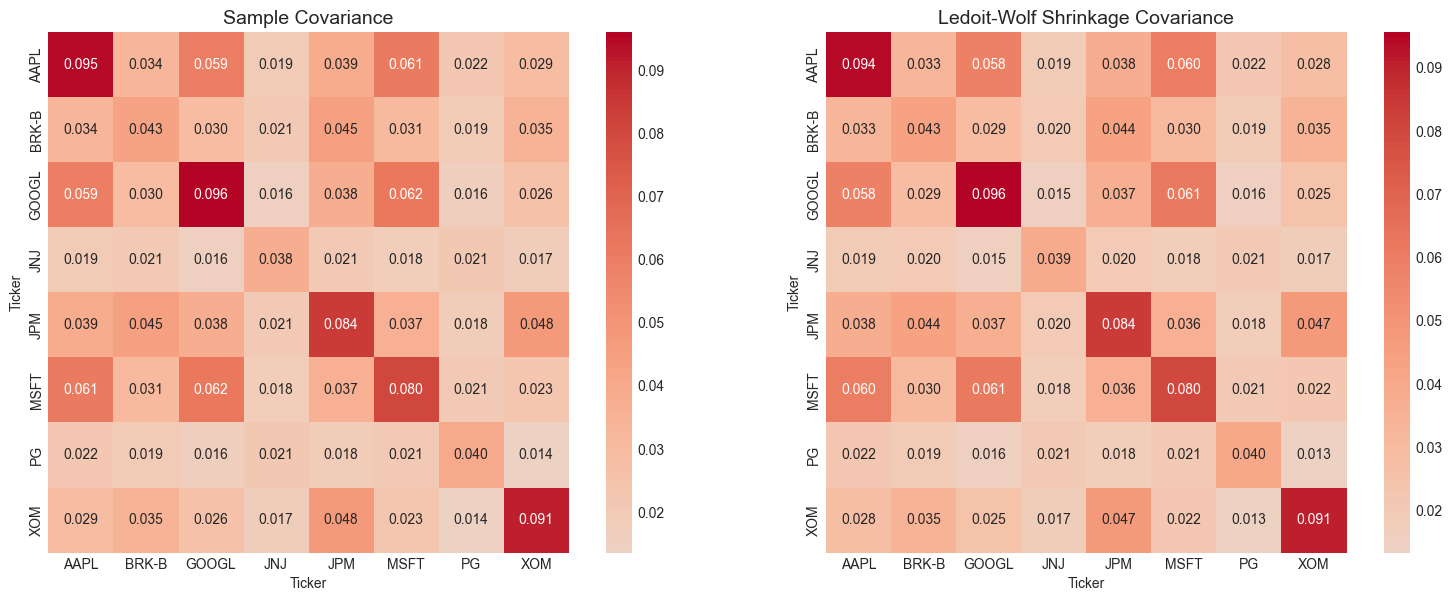

Max Sharpe with Shrinkage Covariance:
  AAPL  :  35.7%
  GOOGL :  15.8%
  JPM   :  10.8%
  MSFT  :  37.6%
Expected annual return: 25.2%
Annual volatility: 25.3%
Sharpe Ratio: 0.84

Shrinkage makes the covariance matrix more "well-behaved".
The off-diagonal elements are pulled toward a common structure.


In [154]:
# ===================================================================
# FIX 1: SHRINKAGE COVARIANCE (Ledoit-Wolf)
# ===================================================================
# The sample covariance matrix is noisy, especially with many stocks
# and limited data. Ledoit-Wolf shrinkage pulls extreme values toward
# a more structured estimate.
#
# Intuition: it's a weighted average of:
#   - The sample covariance (what the data says)
#   - A simple target (e.g., constant correlation matrix)
# The shrinkage intensity is chosen automatically to minimize estimation error.

from pypfopt import risk_models

# Sample covariance (what we've been using)
cov_sample = risk_models.sample_cov(prices)

# Ledoit-Wolf shrinkage
cov_shrunk = risk_models.CovarianceShrinkage(prices).ledoit_wolf()

# Compare
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cov_sample, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], square=True)
axes[0].set_title('Sample Covariance', fontsize=14)

sns.heatmap(cov_shrunk, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[1], square=True)
axes[1].set_title('Ledoit-Wolf Shrinkage Covariance', fontsize=14)

plt.tight_layout()
plt.show()

# Solve MVO with shrunk covariance
ef_shrunk = EfficientFrontier(mu_pypfopt, cov_shrunk)
ef_shrunk.max_sharpe(risk_free_rate=0.04)
w_shrunk = ef_shrunk.clean_weights()

print('Max Sharpe with Shrinkage Covariance:')
for ticker, weight in w_shrunk.items():
    if weight > 0:
        print(f'  {ticker:6s}: {weight*100:5.1f}%')
ef_shrunk.portfolio_performance(verbose=True, risk_free_rate=0.04)

print(f'\nShrinkage makes the covariance matrix more "well-behaved".')
print(f'The off-diagonal elements are pulled toward a common structure.')

Expected Return Estimates (%)
        Historical Mean   CAPM  EMA (1yr span)
Ticker                                        
AAPL              27.11  23.82           38.26
BRK-B             12.48  17.11            9.59
GOOGL             24.92  22.80          116.88
JNJ                8.08  11.36           45.92
JPM               17.95  21.90           42.03
MSFT              25.63  22.13           10.62
PG                 8.84  11.42          -10.97
XOM                9.43  18.78           21.94


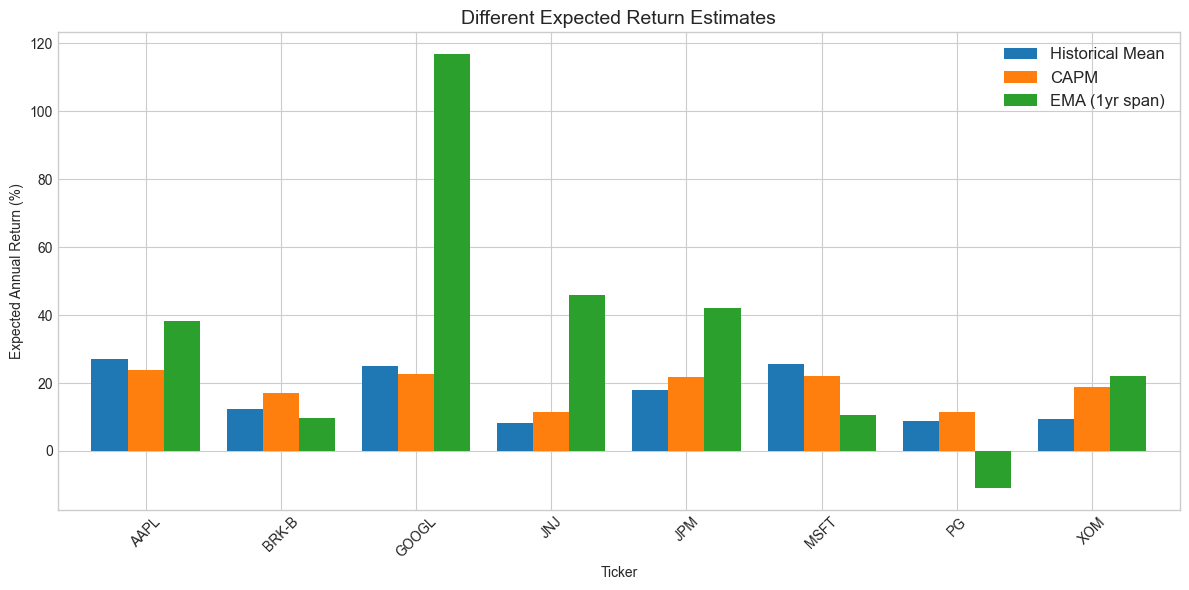


Historical mean: just averages past returns (noisy, backward-looking).
CAPM: implied by market risk (beta × market premium). More stable.
EMA: recent returns weighted more. Adapts to regime changes.


In [155]:
# ===================================================================
# FIX 2: BETTER RETURN ESTIMATES
# ===================================================================
# Historical mean returns are terrible predictors.
# PyPortfolioOpt offers alternatives:

# Method 1: CAPM returns (based on market beta)
mu_capm = expected_returns.capm_return(prices)

# Method 2: Exponentially-weighted mean (recent data matters more)
mu_ema = expected_returns.ema_historical_return(prices, span=252)

# Compare all three
comparison = pd.DataFrame({
    'Historical Mean': mu_pypfopt,
    'CAPM': mu_capm,
    'EMA (1yr span)': mu_ema,
}).round(4) * 100

print('Expected Return Estimates (%)')
print('=' * 60)
print(comparison.to_string())

# Visualize
comparison.plot.bar(figsize=(12, 6), width=0.8)
plt.title('Different Expected Return Estimates', fontsize=14)
plt.ylabel('Expected Annual Return (%)')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('\nHistorical mean: just averages past returns (noisy, backward-looking).')
print('CAPM: implied by market risk (beta × market premium). More stable.')
print('EMA: recent returns weighted more. Adapts to regime changes.')

In [156]:
# ===================================================================
# FIX 3: BLACK-LITTERMAN MODEL
# ===================================================================
# The Black-Litterman model is the most important practical fix.
# 
# Idea: Instead of using historical returns (which are noisy),
# start from MARKET EQUILIBRIUM returns (what the market "believes")
# and then blend in YOUR personal views.
#
# Step 1: Reverse-engineer what returns the market implies
#          (from current market caps and covariance)
# Step 2: Add your subjective views ("I think AAPL will return 20%")
# Step 3: Blend them together (Bayesian update)
#
# Why it works: the market-implied returns are a much better starting
# point than historical means, and they produce more stable weights.

from pypfopt import black_litterman, BlackLittermanModel

# Market capitalizations (in billions, approximate — used as proxy for market views)
# These represent the "size" of each company
market_caps = {
    'AAPL': 3500, 'MSFT': 3200, 'GOOGL': 2200, 'JPM': 700,
    'XOM': 500, 'JNJ': 380, 'PG': 390, 'BRK-B': 1000
}
mcaps = pd.Series(market_caps)

# Step 1: Market-implied returns (what the market "expects")
delta = black_litterman.market_implied_risk_aversion(prices)  # Risk aversion parameter
market_prior = black_litterman.market_implied_prior_returns(mcaps, delta, cov_shrunk)

print('MARKET-IMPLIED RETURNS (Black-Litterman Prior)')
print('=' * 50)
for ticker in market_prior.sort_values(ascending=False).index:
    print(f'  {ticker:6s}: {market_prior[ticker]*100:5.1f}%')

print(f'\nThese are more sensible than historical means because they reflect')
print(f'what the MARKET (all investors combined) implicitly believes.')

MARKET-IMPLIED RETURNS (Black-Litterman Prior)
  MSFT  :  19.2%
  AAPL  :  18.9%
  GOOGL :  16.4%
  BRK-B :  10.4%
  JPM   :   9.8%
  PG    :   5.3%
  JNJ   :   4.7%
  XOM   :   4.4%

These are more sensible than historical means because they reflect
what the MARKET (all investors combined) implicitly believes.


In [157]:
# Step 2 & 3: Add YOUR views and blend

# Your subjective views:
# "I think AAPL will return 15%" (absolute view)
# "I think MSFT will outperform GOOGL by 3%" (relative view)

viewdict = {
    'AAPL': 0.15,    # I believe AAPL will return 15%
    'MSFT': 0.12,    # I believe MSFT will return 12%
    'XOM': 0.05,     # I'm bearish on XOM: only 5%
}

bl = BlackLittermanModel(
    cov_shrunk,
    pi=market_prior,          # Start from market equilibrium
    absolute_views=viewdict,  # Blend in my views
)

# Get the blended (posterior) expected returns
bl_returns = bl.bl_returns()

# Compare: market prior vs. your views vs. blended result
comparison_bl = pd.DataFrame({
    'Market Prior': market_prior * 100,
    'Your Views': pd.Series({t: v*100 for t, v in viewdict.items()}),
    'BL Blended': bl_returns * 100,
}).round(1)

print('BLACK-LITTERMAN: Blending Market + Your Views')
print('=' * 60)
print(comparison_bl.to_string())

print(f'\nNotice: BL returns are between the market prior and your views.')
print(f'Stocks you have views on get pulled toward your estimates.')
print(f'Stocks with no views stay near the market equilibrium.')

BLACK-LITTERMAN: Blending Market + Your Views
       Market Prior  Your Views  BL Blended
AAPL           18.9        15.0        15.8
BRK-B          10.4         NaN         9.2
GOOGL          16.4         NaN        13.5
JNJ             4.7         NaN         4.0
JPM             9.8         NaN         8.3
MSFT           19.2        12.0        15.5
PG              5.3         NaN         4.3
XOM             4.4         5.0         4.1

Notice: BL returns are between the market prior and your views.
Stocks you have views on get pulled toward your estimates.
Stocks with no views stay near the market equilibrium.


In [158]:
# Use Black-Litterman returns in MVO

bl_cov = bl.bl_cov()  # Black-Litterman also adjusts the covariance

ef_bl = EfficientFrontier(bl_returns, bl_cov)
ef_bl.max_sharpe(risk_free_rate=0.04)
w_bl = ef_bl.clean_weights()

print('BLACK-LITTERMAN MAX SHARPE PORTFOLIO')
print('=' * 50)
for ticker, weight in w_bl.items():
    if weight > 0:
        print(f'  {ticker:6s}: {weight*100:5.1f}%')

ef_bl.portfolio_performance(verbose=True, risk_free_rate=0.04)

print(f'\nCompare to the basic MVO weights — Black-Litterman is more diversified')
print(f'and more stable because it starts from a sensible equilibrium.')

BLACK-LITTERMAN MAX SHARPE PORTFOLIO
  AAPL  :  38.8%
  BRK-B :   4.4%
  MSFT  :  56.7%
Expected annual return: 15.3%
Annual volatility: 26.6%
Sharpe Ratio: 0.43

Compare to the basic MVO weights — Black-Litterman is more diversified
and more stable because it starts from a sensible equilibrium.


EFFECT OF L2 REGULARIZATION (gamma)
  gamma=0.0: Sharpe=0.834, Stocks held=4, Max weight=38%
  gamma=0.1: Sharpe=0.827, Stocks held=5, Max weight=31%
  gamma=0.5: Sharpe=0.806, Stocks held=8, Max weight=25%
  gamma=1.0: Sharpe=0.799, Stocks held=8, Max weight=24%
  gamma=2.0: Sharpe=0.795, Stocks held=8, Max weight=23%


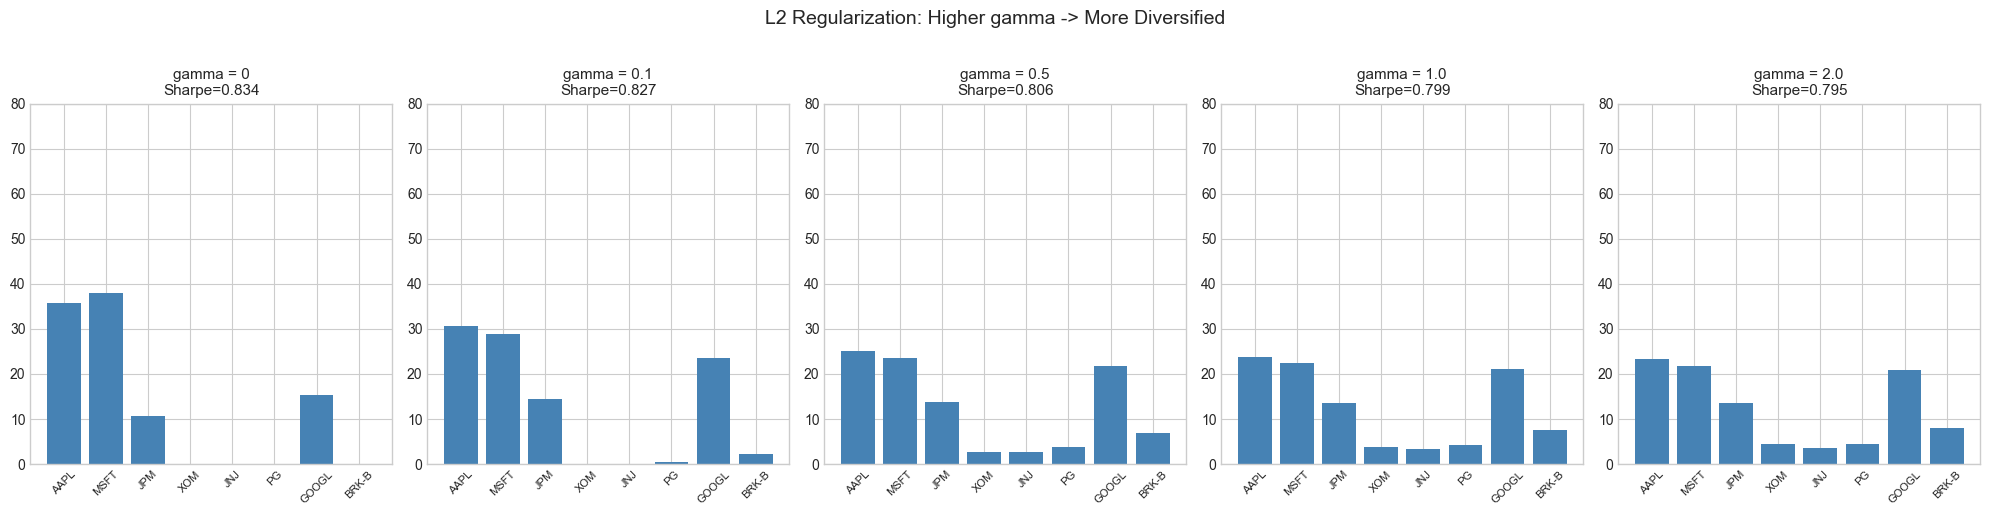


gamma=0: pure MVO (concentrated). gamma=2: forced diversification (all stocks held).
In practice, gamma between 0.1 and 1.0 works well.


In [159]:
# ===================================================================
# FIX 4: L2 REGULARIZATION
# ===================================================================
# Another trick: add a penalty for extreme weights.
# This is called L2 regularization (or "gamma" in pypfopt).
# It penalizes concentrated portfolios, pushing toward diversification.
#
# Objective becomes: maximize Sharpe - gamma * ||w||^2
# Higher gamma -> more diversified (but lower Sharpe)

import cvxpy as cp

gammas = [0, 0.1, 0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, len(gammas), figsize=(20, 5))

print("EFFECT OF L2 REGULARIZATION (gamma)")
print("=" * 60)

for idx, gamma in enumerate(gammas):
    ef_reg = EfficientFrontier(mu_pypfopt, cov_pypfopt)
    # pypfopt uses cvxpy internally -- use cp.sum_squares for the L2 penalty
    ef_reg.add_objective(lambda w: gamma * cp.sum_squares(w))
    ef_reg.max_sharpe(risk_free_rate=0.04)
    w_reg = ef_reg.clean_weights()
    
    # Count non-zero weights
    n_held = sum(1 for v in w_reg.values() if v > 0.01)
    ret, vol, sr = ef_reg.portfolio_performance(risk_free_rate=0.04)
    
    print(f"  gamma={gamma:.1f}: Sharpe={sr:.3f}, Stocks held={n_held}, "
          f"Max weight={max(w_reg.values())*100:.0f}%")
    
    # Plot
    weights_list = [w_reg.get(t, 0) * 100 for t in TICKERS]
    axes[idx].bar(TICKERS, weights_list, color="steelblue")
    axes[idx].set_title(f"gamma = {gamma}" + chr(10) + f"Sharpe={sr:.3f}", fontsize=11)
    axes[idx].set_ylim(0, 80)
    axes[idx].tick_params(axis="x", rotation=45, labelsize=8)

plt.suptitle("L2 Regularization: Higher gamma -> More Diversified", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print()
print("gamma=0: pure MVO (concentrated). gamma=2: forced diversification (all stocks held).")
print("In practice, gamma between 0.1 and 1.0 works well.")

### Summary of Fixes

| Fix | What it does | When to use |
|-----|-------------|-------------|
| **Shrinkage covariance** | Makes Σ more stable | Always — free improvement |
| **CAPM / EMA returns** | Better μ estimates | When you don't have strong views |
| **Black-Litterman** | Blend market + your views | When you have specific views on some stocks |
| **L2 regularization** | Force diversification | When MVO gives extreme weights |
| **Constraints** | Hard limits on weights | Always — prevents blow-ups |

**The practitioner's recipe:**
1. Use Ledoit-Wolf shrinkage for covariance (always)
2. Use Black-Litterman for returns (if you have views) or CAPM/equal returns (if you don't)
3. Add position limits (max 15-25% per stock)
4. Add sector constraints if applicable
5. Optionally add L2 regularization

---
---
# Part 7: Out-of-Sample Test — Does MVO Actually Work?
---
---

The ultimate test: use historical data to compute MVO weights, then see how the portfolio performs on FUTURE (unseen) data.

### Setup

```
2018─────────────2022│2022─────────────2025
   Training window   │   Test window
   Estimate μ and Σ  │   Measure actual performance
```

We'll compare:
1. **MVO (basic)** — historical mean + sample covariance
2. **MVO (robust)** — shrinkage covariance + position limits
3. **Black-Litterman MVO** — market-implied returns + shrinkage
4. **Equal weight** — 1/N in each stock (naive benchmark)
5. **Market cap weight** — weight by company size

In [160]:
# ===================================================================
# OUT-OF-SAMPLE BACKTEST
# ===================================================================

# Split data
split_date = '2022-06-01'
prices_train = prices.loc[:split_date]
prices_test = prices.loc[split_date:]
returns_test = prices_test.pct_change().dropna()

print(f'Training: {prices_train.index[0].date()} to {prices_train.index[-1].date()} ({len(prices_train)} days)')
print(f'Testing:  {prices_test.index[0].date()} to {prices_test.index[-1].date()} ({len(prices_test)} days)')

# --- Strategy 1: Basic MVO (max Sharpe) ---
mu_train = expected_returns.mean_historical_return(prices_train)
cov_train = risk_models.sample_cov(prices_train)

ef1 = EfficientFrontier(mu_train, cov_train)
ef1.max_sharpe(risk_free_rate=0.04)
w1 = ef1.clean_weights()

# --- Strategy 2: Robust MVO (shrinkage + position limits) ---
cov_train_shrunk = risk_models.CovarianceShrinkage(prices_train).ledoit_wolf()

ef2 = EfficientFrontier(mu_train, cov_train_shrunk, weight_bounds=(0, 0.25))
ef2.max_sharpe(risk_free_rate=0.04)
w2 = ef2.clean_weights()

# --- Strategy 3: Minimum Variance (no return estimate needed) ---
ef3 = EfficientFrontier(mu_train, cov_train_shrunk)
ef3.min_volatility()
w3 = ef3.clean_weights()

# --- Strategy 4: Equal Weight ---
w4 = {t: 1/n_assets for t in TICKERS}

# --- Strategy 5: Market Cap Weight ---
total_mcap = sum(market_caps.values())
w5 = {t: market_caps[t] / total_mcap for t in TICKERS}

# Collect all strategies
strategies = {
    'Basic MVO': w1,
    'Robust MVO': w2,
    'Min Variance': w3,
    'Equal Weight': w4,
    'Market Cap': w5,
}

# Print weights
print(f'\nWeights (computed from training data):')
print('=' * 70)
weight_comparison = pd.DataFrame(strategies).round(3) * 100
print(weight_comparison.to_string())

Training: 2018-01-02 to 2022-06-01 (1112 days)
Testing:  2022-06-01 to 2025-12-30 (899 days)

Weights (computed from training data):
       Basic MVO  Robust MVO  Min Variance  Equal Weight  Market Cap
AAPL        46.3        25.0           0.0          12.5        29.5
BRK-B        0.0         3.9          18.7          12.5         8.4
GOOGL        0.0        14.0           8.4          12.5        18.5
JNJ          0.0         7.1          33.9          12.5         3.2
JPM          0.0         0.0           0.0          12.5         5.9
MSFT        51.7        25.0           0.0          12.5        27.0
PG           2.0        25.0          33.4          12.5         3.3
XOM          0.0         0.0           5.6          12.5         4.2


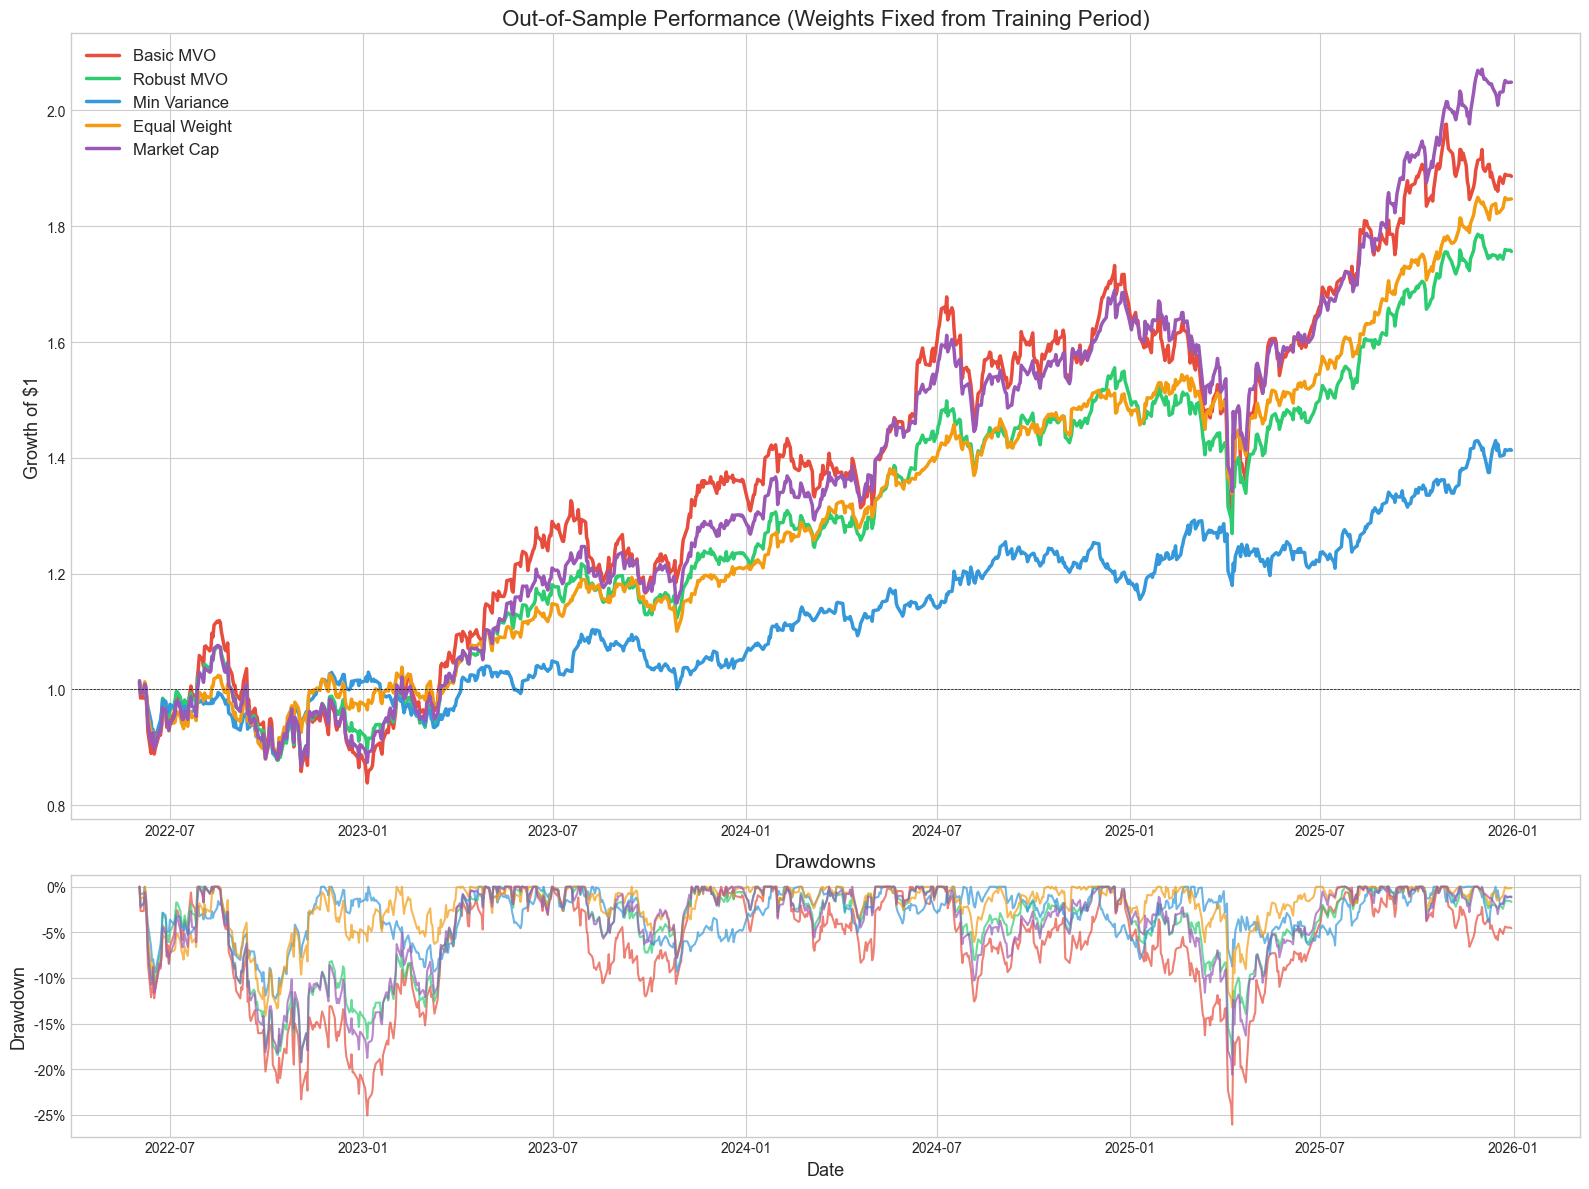

OUT-OF-SAMPLE RESULTS
    Strategy Total Return Annual Return Annual Vol Sharpe Max Drawdown
   Basic MVO        88.6%         19.5%      23.3%  0.665       -26.1%
  Robust MVO        75.6%         17.1%      17.2%  0.763       -19.2%
Min Variance        41.3%         10.2%      12.6%  0.491       -12.3%
Equal Weight        84.7%         18.8%      14.7%  1.008       -14.1%
  Market Cap       104.9%         22.3%      19.8%  0.926       -20.6%


In [161]:
# ===================================================================
# MEASURE OUT-OF-SAMPLE PERFORMANCE
# ===================================================================

fig, axes = plt.subplots(2, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1]})

results_oos = []
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for idx, (name, weights) in enumerate(strategies.items()):
    # Convert weights dict to array aligned with returns columns
    w_arr = np.array([weights.get(t, 0) for t in returns_test.columns])
    
    # Portfolio daily returns = weighted sum of stock returns
    port_rets = returns_test.values @ w_arr
    port_rets = pd.Series(port_rets, index=returns_test.index)
    
    # Cumulative returns
    cum_rets = (1 + port_rets).cumprod()
    
    # Metrics
    total_ret = cum_rets.iloc[-1] - 1
    n_years = len(port_rets) / 252
    annual_ret = (1 + total_ret) ** (1 / n_years) - 1
    annual_vol = port_rets.std() * np.sqrt(252)
    sharpe = (annual_ret - 0.04) / annual_vol
    max_dd = (cum_rets / cum_rets.cummax() - 1).min()
    
    results_oos.append({
        'Strategy': name,
        'Total Return': f'{total_ret*100:.1f}%',
        'Annual Return': f'{annual_ret*100:.1f}%',
        'Annual Vol': f'{annual_vol*100:.1f}%',
        'Sharpe': f'{sharpe:.3f}',
        'Max Drawdown': f'{max_dd*100:.1f}%',
    })
    
    # Plot cumulative returns
    axes[0].plot(cum_rets.index, cum_rets.values, label=name,
                 linewidth=2.5, color=colors[idx])
    
    # Plot drawdown
    dd = cum_rets / cum_rets.cummax() - 1
    axes[1].plot(dd.index, dd.values, color=colors[idx], alpha=0.7, linewidth=1.5)

axes[0].set_title('Out-of-Sample Performance (Weights Fixed from Training Period)',
                   fontsize=16)
axes[0].set_ylabel('Growth of $1', fontsize=13)
axes[0].legend(fontsize=12)
axes[0].axhline(y=1, color='black', linewidth=0.5, linestyle='--')

axes[1].set_title('Drawdowns', fontsize=14)
axes[1].set_ylabel('Drawdown', fontsize=13)
axes[1].set_xlabel('Date', fontsize=13)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.tight_layout()
plt.show()

# Results table
print('OUT-OF-SAMPLE RESULTS')
print('=' * 80)
print(pd.DataFrame(results_oos).to_string(index=False))

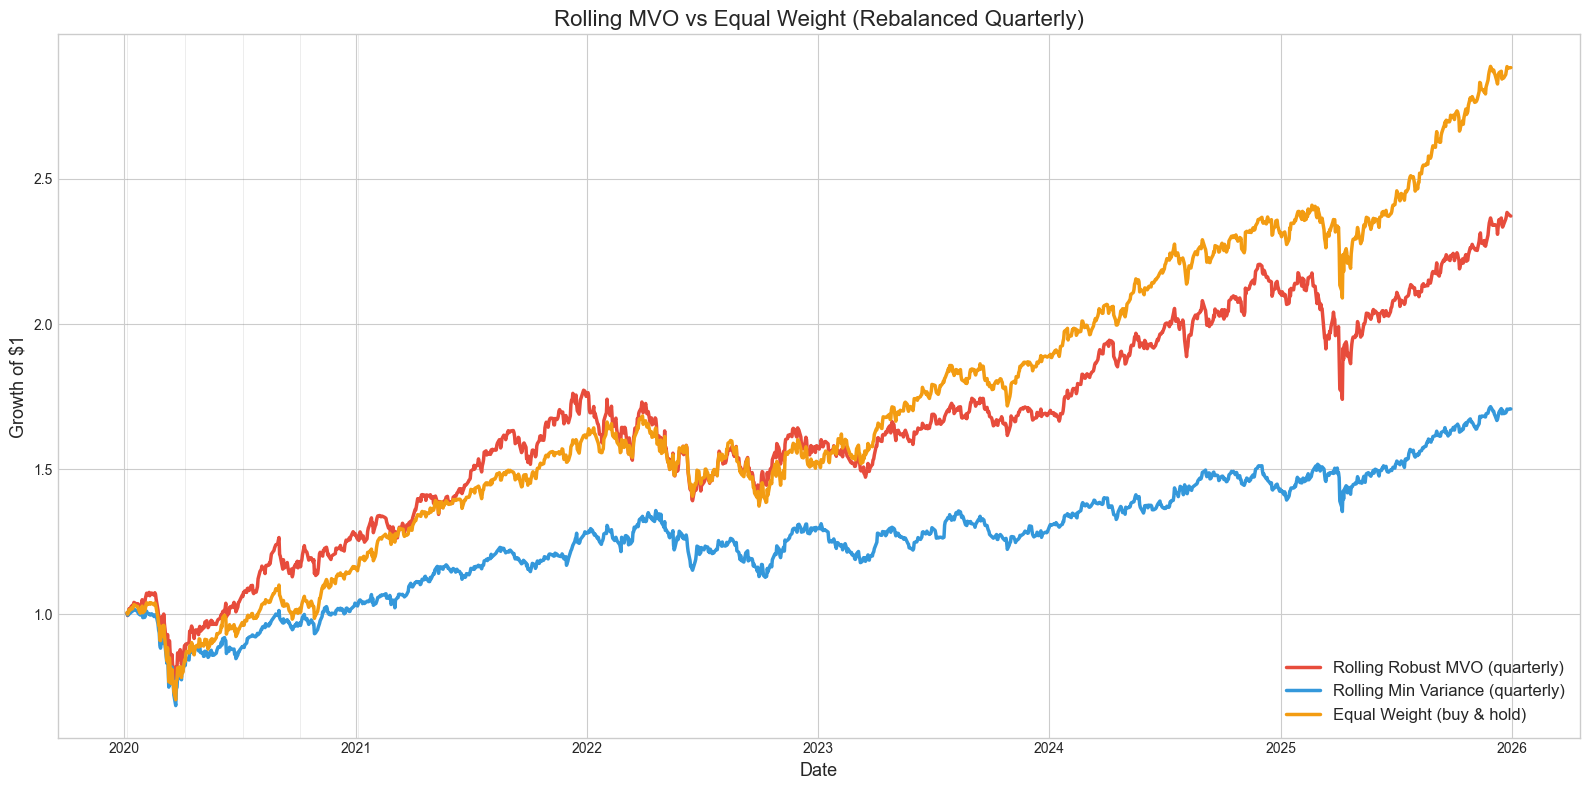


ROLLING BACKTEST RESULTS
            Strategy Annual Return Annual Vol Sharpe Max DD
  Rolling Robust MVO         15.6%      21.4%  0.540 -30.0%
Rolling Min Variance          9.4%      17.4%  0.309 -32.7%
        Equal Weight         19.4%      19.6%  0.787 -32.1%


In [162]:
# ===================================================================
# ROLLING MVO — Rebalance Periodically
# ===================================================================
# In practice, you don't set weights once and forget. You REBALANCE
# periodically (e.g., quarterly) using the most recent data.
#
# Rolling approach:
#   - Every quarter, use the past 2 years of data to estimate μ and Σ
#   - Solve MVO to get new weights
#   - Hold for 1 quarter, then repeat

lookback = 504  # ~2 years of trading days
rebalance_freq = 63  # ~quarterly (63 trading days)

# We'll track the rolling MVO portfolio vs equal-weight
all_returns = prices.pct_change().dropna()
dates = all_returns.index

rolling_port_rets = []
rolling_eq_rets = []
rolling_minvar_rets = []
rolling_dates = []
current_weights_mvo = np.array([1/n_assets] * n_assets)
current_weights_eq = np.array([1/n_assets] * n_assets)
current_weights_mv = np.array([1/n_assets] * n_assets)

rebalance_dates = []

for i in range(lookback, len(dates)):
    # Rebalance?
    if (i - lookback) % rebalance_freq == 0:
        # Use past 'lookback' days to estimate
        train_prices = prices.iloc[i-lookback:i]
        
        try:
            mu_roll = expected_returns.mean_historical_return(train_prices)
            cov_roll = risk_models.CovarianceShrinkage(train_prices).ledoit_wolf()
            
            # Robust MVO
            ef_roll = EfficientFrontier(mu_roll, cov_roll, weight_bounds=(0.02, 0.25))
            ef_roll.max_sharpe(risk_free_rate=0.04)
            w_clean = ef_roll.clean_weights()
            current_weights_mvo = np.array([w_clean.get(t, 0) for t in all_returns.columns])
            
            # Min variance
            ef_mv = EfficientFrontier(mu_roll, cov_roll)
            ef_mv.min_volatility()
            w_mv = ef_mv.clean_weights()
            current_weights_mv = np.array([w_mv.get(t, 0) for t in all_returns.columns])
            
            rebalance_dates.append(dates[i])
        except Exception:
            pass  # Keep previous weights if optimization fails
    
    # Daily return for each strategy
    daily_ret = all_returns.iloc[i].values
    rolling_port_rets.append(daily_ret @ current_weights_mvo)
    rolling_eq_rets.append(daily_ret @ current_weights_eq)
    rolling_minvar_rets.append(daily_ret @ current_weights_mv)
    rolling_dates.append(dates[i])

# Convert to Series
rolling_mvo = pd.Series(rolling_port_rets, index=rolling_dates)
rolling_eq = pd.Series(rolling_eq_rets, index=rolling_dates)
rolling_mv = pd.Series(rolling_minvar_rets, index=rolling_dates)

# Plot
fig, ax = plt.subplots(figsize=(16, 8))

cum_mvo = (1 + rolling_mvo).cumprod()
cum_eq = (1 + rolling_eq).cumprod()
cum_mv = (1 + rolling_mv).cumprod()

ax.plot(cum_mvo.index, cum_mvo.values, label='Rolling Robust MVO (quarterly)', linewidth=2.5, color='#e74c3c')
ax.plot(cum_mv.index, cum_mv.values, label='Rolling Min Variance (quarterly)', linewidth=2.5, color='#3498db')
ax.plot(cum_eq.index, cum_eq.values, label='Equal Weight (buy & hold)', linewidth=2.5, color='#f39c12')

# Mark rebalance dates
for rd in rebalance_dates[:5]:  # Show first few
    ax.axvline(x=rd, color='gray', alpha=0.2, linewidth=0.5)

ax.set_title('Rolling MVO vs Equal Weight (Rebalanced Quarterly)', fontsize=16)
ax.set_ylabel('Growth of $1', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

# Metrics
def calc_metrics(rets, name):
    cum = (1 + rets).cumprod()
    total = cum.iloc[-1] - 1
    n_years = len(rets) / 252
    annual_ret = (1 + total) ** (1/n_years) - 1
    annual_vol = rets.std() * np.sqrt(252)
    sharpe = (annual_ret - 0.04) / annual_vol
    max_dd = (cum / cum.cummax() - 1).min()
    return {'Strategy': name, 'Annual Return': f'{annual_ret*100:.1f}%',
            'Annual Vol': f'{annual_vol*100:.1f}%', 'Sharpe': f'{sharpe:.3f}',
            'Max DD': f'{max_dd*100:.1f}%'}

print('\nROLLING BACKTEST RESULTS')
print('=' * 70)
metrics = [
    calc_metrics(rolling_mvo, 'Rolling Robust MVO'),
    calc_metrics(rolling_mv, 'Rolling Min Variance'),
    calc_metrics(rolling_eq, 'Equal Weight'),
]
print(pd.DataFrame(metrics).to_string(index=False))

---
---
# Key Takeaways
---
---

### What MVO IS
- A mathematical framework for finding the best risk-return tradeoff
- Given expected returns (μ) and covariance (Σ), it finds optimal weights
- The efficient frontier shows all optimal portfolios

### What MVO is NOT
- A magic money machine — it's only as good as your inputs
- A set-and-forget tool — you need to rebalance and update
- A substitute for understanding the stocks you're buying

### The Practitioner's Checklist

```
1. Estimate covariance → USE SHRINKAGE (Ledoit-Wolf), not sample covariance
2. Estimate returns   → USE Black-Litterman or CAPM, not historical mean
3. Add constraints    → Max 15-25% per stock, sector limits
4. Add regularization → L2 penalty to prevent concentration
5. Backtest properly  → Out-of-sample, account for transaction costs
6. Rebalance          → Quarterly is typical, with turnover limits
```

### Code Cheat Sheet

```python
from pypfopt import expected_returns, risk_models, EfficientFrontier

# The 5-line version:
mu = expected_returns.capm_return(prices)
cov = risk_models.CovarianceShrinkage(prices).ledoit_wolf()
ef = EfficientFrontier(mu, cov, weight_bounds=(0.02, 0.25))
ef.max_sharpe(risk_free_rate=0.04)
weights = ef.clean_weights()
```

In [163]:
print('NOTEBOOK COMPLETE!')
print('=' * 50)
print('What you now know:')
print('  1. The two inputs MVO needs (μ and Σ) and how to compute them')
print('  2. How to solve MVO from scratch with scipy')
print('  3. How to plot and interpret the efficient frontier')
print('  4. How to add real-world constraints')
print('  5. How to use PyPortfolioOpt (the practical library)')
print('  6. Why textbook MVO fails and the fixes (shrinkage, Black-Litterman, regularization)')
print('  7. How to backtest MVO out-of-sample with rolling rebalancing')

NOTEBOOK COMPLETE!
What you now know:
  1. The two inputs MVO needs (μ and Σ) and how to compute them
  2. How to solve MVO from scratch with scipy
  3. How to plot and interpret the efficient frontier
  4. How to add real-world constraints
  5. How to use PyPortfolioOpt (the practical library)
  6. Why textbook MVO fails and the fixes (shrinkage, Black-Litterman, regularization)
  7. How to backtest MVO out-of-sample with rolling rebalancing
